In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set up visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Alternative: using relative path from current directory
csv_path = 'df_snapshot_csv/part-00000-cf09ea0d-f069-4278-80e7-ba6e8ecb450e-c000.csv'

# Load the CSV file
df = pd.read_csv(csv_path)

print(f"Data loaded successfully!")
print(f"File path: {csv_path}")

Data loaded successfully!
File path: df_snapshot_csv/part-00000-cf09ea0d-f069-4278-80e7-ba6e8ecb450e-c000.csv


In [4]:
df.head()

,trans_id,ac_from,ac_to,data_date,trans_initiate_time,cutoff_date,fraud_flag,trx_channel,trx_type,start_balance,...,user_avg_amount_per_recipient_7d,user_max_amount_to_single_recipient_7d,user_recipient_concentration_ratio_7d,user_avg_time_between_txns_7d,user_txn_frequency_score_7d,user_first_txn_time,user_last_txn_time,user_days_since_last_txn,processing_timestamp,created_at
0,81953057607,+gCT0E+hwmtNDciP/Axgww==,NaN,2025-06-01,2025-06-01T03:38:27.000+05:00,2025-06-01,0,NEW_JC_APP,Utility Bills Payment,600.40,...,NaN,0.00,0.666667,8.000000,3.000000,2025-06-01T03:38:27.000+05:00,2025-06-01T19:55:37.000+05:00,0,2025-10-28T15:32:05.000+05:00,2025-10-28
1,81953066486,+gCT0E+hwmtNDciP/Axgww==,890GkQp1V1kBtx9Oc3GZyA==,2025-06-01,2025-06-01T03:39:11.000+05:00,2025-06-01,0,NEW_JC_APP,Transfer(C2C),0.00,...,NaN,0.00,0.666667,8.000000,3.000000,2025-06-01T03:38:27.000+05:00,2025-06-01T19:55:37.000+05:00,0,2025-10-28T15:32:05.000+05:00,2025-10-28
2,82003248726,+qqxPm4Yl4jFEXkN23Qx2w==,UvfgoPVIxrrZvWAl15VbCQ==,2025-06-01,2025-06-01T20:44:57.000+05:00,2025-06-01,0,NEW_JC_APP,Transfer(C2C),7142.16,...,4651.643333,12494.16,0.375000,16.857143,1.333333,2025-05-27T22:53:35.000+05:00,2025-06-01T20:44:57.000+05:00,0,2025-10-28T15:32:05.000+05:00,2025-10-28
3,81964499353,BGmPB0sbJFoZJ09ksMPfLw==,hm/xVzbvGuAMRk3aaPzlBw==,2025-06-01,2025-06-01T10:30:04.000+05:00,2025-06-01,0,NEW_JC_APP,Merchant Payment,214.00,...,147.333333,214.00,1.000000,12.166667,1.750000,2025-05-29T09:52:28.000+05:00,2025-06-01T10:30:04.000+05:00,0,2025-10-28T15:32:05.000+05:00,2025-10-28
4,81993831451,V0KUbJlzRpqpIH27gfWJmg==,EcDbTSq/pC5bq1D2YpzBHg==,2025-06-01,2025-06-01T18:31:57.000+05:00,2025-06-01,0,NEW_JC_APP,Transfer(C2C),0.00,...,NaN,0.00,1.000000,0.000000,1.000000,2025-06-01T18:31:57.000+05:00,2025-06-01T18:31:57.000+05:00,0,2025-10-28T15:32:05.000+05:00,2025-10-28


In [5]:
selected_cols = [
    'ac_from',
    'ac_to',
    'fraud_flag',
    'trx_channel',
    'trx_type',
    'start_balance',
    'trx_amt',
    'mbar_region',
    'mbar_city',
    'mbar_registered_channel',
    'mbar_registered_date_time',
    'mbar_a_c_status',
    'mbar_a_c_level',
    'mbar_agent_group',
    'mbar_limit_group',
    'mbar_charge_profile',
    'mbar_credit_dl_ml_yl',
    'mbar_debit_dl_ml_yl',
    'mbar_year_of_birth',
    'mbar_last_modified_date_time',
    'mbar_dormant_date',
    'mbar_re_active_date',
    'mbar_place_of_birth',
    'mbar_account_type_name',
    'hour_of_day',
    'day_of_week',
    'is_weekend',
    'is_night',
    'is_business_hours',
    'is_unusual_hour',
    'night_weekend_combo',
    'start_balance_log',
    'balance_change',
    'balance_change_pct',
    'txn_txns_3d',
    'txn_total_amount_3d',
    'txn_avg_amount_3d',
    'txn_max_amount_3d',
    'txn_min_amount_3d',
    'txn_unique_recipients_3d',
    'txn_unique_channels_3d',
    'txn_unique_types_3d',
    'txn_is_high_activity_3d',
    'txn_multi_channel_recent',
    'txn_amount_deviation_from_avg',
    'txn_night_txns_3d',
    'txn_weekend_txns_3d',
    'user_total_txns_3d',
    'user_total_amount_3d',
    'user_avg_amount_3d',
    'user_median_amount_3d',
    'user_max_amount_3d',
    'user_min_amount_3d',
    'user_unique_recipients_3d',
    'user_unique_channels_3d',
    'user_unique_types_3d',
    'user_total_txns_7d',
    'user_total_amount_7d',
    'user_avg_amount_7d',
    'user_median_amount_7d',
    'user_max_amount_7d',
    'user_min_amount_7d',
    'user_unique_recipients_7d',
    'user_unique_channels_7d',
    'user_unique_types_7d',
    'user_most_used_channel_7d',
    'user_last_used_channel',
    'user_channel_diversity_score_7d',
    'user_most_used_type_7d',
    'user_last_used_type',
    'user_type_diversity_score_7d',
    'user_night_txns_7d',
    'user_weekend_txns_7d',
    'user_peak_hour_txns_7d',
    'user_off_peak_hour_txns_7d',
    'user_avg_start_balance_7d',
    'user_avg_end_balance_7d',
    'user_min_balance_7d',
    'user_max_balance_7d',
    'user_balance_volatility_7d',
    'user_avg_amount_per_recipient_7d',
    'user_max_amount_to_single_recipient_7d',
    'user_recipient_concentration_ratio_7d',
    'user_avg_time_between_txns_7d',
    'user_txn_frequency_score_7d',
    'user_days_since_last_txn',
    ]

In [6]:
df_sm = df[selected_cols].copy()

In [7]:
df_sm.head()

,ac_from,ac_to,fraud_flag,trx_channel,trx_type,start_balance,trx_amt,mbar_region,mbar_city,mbar_registered_channel,...,user_avg_end_balance_7d,user_min_balance_7d,user_max_balance_7d,user_balance_volatility_7d,user_avg_amount_per_recipient_7d,user_max_amount_to_single_recipient_7d,user_recipient_concentration_ratio_7d,user_avg_time_between_txns_7d,user_txn_frequency_score_7d,user_days_since_last_txn
0,+gCT0E+hwmtNDciP/Axgww==,NaN,0,NEW_JC_APP,Utility Bills Payment,600.40,597.0,NaN,NaN,NEW_JC_APP,...,NaN,0.00,0.00,NaN,NaN,0.00,0.666667,8.000000,3.000000,0
1,+gCT0E+hwmtNDciP/Axgww==,890GkQp1V1kBtx9Oc3GZyA==,0,NEW_JC_APP,Transfer(C2C),0.00,25000.0,NaN,NaN,NEW_JC_APP,...,NaN,0.00,0.00,NaN,NaN,0.00,0.666667,8.000000,3.000000,0
2,+qqxPm4Yl4jFEXkN23Qx2w==,UvfgoPVIxrrZvWAl15VbCQ==,0,NEW_JC_APP,Transfer(C2C),7142.16,36100.0,NaN,NaN,USSD_API,...,14336.015714,47.17,31547.17,7626.060910,4651.643333,12494.16,0.375000,16.857143,1.333333,0
3,BGmPB0sbJFoZJ09ksMPfLw==,hm/xVzbvGuAMRk3aaPzlBw==,0,NEW_JC_APP,Merchant Payment,214.00,100.0,NaN,NaN,NEW_JC_APP,...,47.333333,14.00,214.00,47.140452,147.333333,214.00,1.000000,12.166667,1.750000,0
4,V0KUbJlzRpqpIH27gfWJmg==,EcDbTSq/pC5bq1D2YpzBHg==,0,NEW_JC_APP,Transfer(C2C),0.00,500.0,NaN,NaN,NEW_JC_APP,...,NaN,0.00,0.00,NaN,NaN,0.00,1.000000,0.000000,1.000000,0


In [33]:
df['fraud_flag'].sum()

np.int64(494)

In [8]:
# Check the structure of ac_from and ac_to columns
print("Sample ac_from values:")
print(df_sm['ac_from'].head(10).tolist())
print("\nSample ac_to values:")
print(df_sm['ac_to'].head(10).tolist())
print(f"\nUnique ac_from count: {df_sm['ac_from'].nunique()}")
print(f"Unique ac_to count: {df_sm['ac_to'].nunique()}")
print(f"Total unique accounts: {pd.concat([df_sm['ac_from'], df_sm['ac_to']]).nunique()}")

Sample ac_from values:
['+gCT0E+hwmtNDciP/Axgww==', '+gCT0E+hwmtNDciP/Axgww==', '+qqxPm4Yl4jFEXkN23Qx2w==', 'BGmPB0sbJFoZJ09ksMPfLw==', 'V0KUbJlzRpqpIH27gfWJmg==', '+rvj90yFvl1+jBeZWXmt6w==', 'kM9KOVnf8XY00WgqDYyuTQ==', '/D55k1T5GWjANhfjubti8w==', '/QRlt6LP/rXls1Tn2L9dSA==', '/QRlt6LP/rXls1Tn2L9dSA==']

Sample ac_to values:
[nan, '890GkQp1V1kBtx9Oc3GZyA==', 'UvfgoPVIxrrZvWAl15VbCQ==', 'hm/xVzbvGuAMRk3aaPzlBw==', 'EcDbTSq/pC5bq1D2YpzBHg==', 'JUsOFvS65DazhwbCodyf6w==', 'grCLfWu7VQ6XVDsqcyRprg==', '+qqxPm4Yl4jFEXkN23Qx2w==', '3tnCDStornb12QEd8izHLw==', 'TFKPfNaCYqRcHq4MpoHU5w==']

Unique ac_from count: 14165
Unique ac_to count: 10792
Total unique accounts: 22945


In [9]:
# Create account ID mapping
# Get all unique account IDs from both ac_from and ac_to columns
all_accounts = pd.concat([df_sm['ac_from'], df_sm['ac_to']]).dropna().unique()

print(f"Total unique account IDs: {len(all_accounts)}")

# Create mapping dictionary from hash to sequential ID
account_to_id = {account_hash: idx for idx, account_hash in enumerate(sorted(all_accounts))}

# Create reverse mapping for reference (ID to hash)
id_to_account = {idx: account_hash for account_hash, idx in account_to_id.items()}

print(f"Account mapping created: {len(account_to_id)} mappings")
print("\nSample mappings:")
for i, (hash_val, id_val) in enumerate(list(account_to_id.items())[:5]):
    print(f"  {hash_val[:20]}... -> ID: {id_val}")

Total unique account IDs: 22945
Account mapping created: 22945 mappings

Sample mappings:
  ++7P2+u72hGDE8f7nxGM... -> ID: 0
  ++byQqQQoLkpiq++SmGE... -> ID: 1
  ++yAlSll4CcdySEyBDbb... -> ID: 2
  +/CMuMhHKCp/OXl/6Wil... -> ID: 3
  +/P7TbXyL2hhoCAhrsqs... -> ID: 4


In [10]:
# Apply mapping to create new ID columns
# Map ac_from to ac_from_id
df_sm['ac_from_id'] = df_sm['ac_from'].map(account_to_id)

# Map ac_to to ac_to_id (handle NaN values)
df_sm['ac_to_id'] = df_sm['ac_to'].map(account_to_id)

print("ID mapping applied successfully!")
print(f"ac_from_id null count: {df_sm['ac_from_id'].isnull().sum()}")
print(f"ac_to_id null count: {df_sm['ac_to_id'].isnull().sum()}")

# Display comparison of original vs mapped values
print("\nComparison of original vs mapped values:")
comparison_df = df_sm[['ac_from', 'ac_from_id', 'ac_to', 'ac_to_id']].head(10)
print(comparison_df)

ID mapping applied successfully!
ac_from_id null count: 0
ac_to_id null count: 4128

Comparison of original vs mapped values:
                    ac_from  ac_from_id                     ac_to  ac_to_id
0  +gCT0E+hwmtNDciP/Axgww==         222                       NaN       NaN
1  +gCT0E+hwmtNDciP/Axgww==         222  890GkQp1V1kBtx9Oc3GZyA==    3639.0
2  +qqxPm4Yl4jFEXkN23Qx2w==         270  UvfgoPVIxrrZvWAl15VbCQ==   11782.0
3  BGmPB0sbJFoZJ09ksMPfLw==        4718  hm/xVzbvGuAMRk3aaPzlBw==   16407.0
4  V0KUbJlzRpqpIH27gfWJmg==       11805  EcDbTSq/pC5bq1D2YpzBHg==    5939.0
5  +rvj90yFvl1+jBeZWXmt6w==         280  JUsOFvS65DazhwbCodyf6w==    7669.0
6  kM9KOVnf8XY00WgqDYyuTQ==       17373  grCLfWu7VQ6XVDsqcyRprg==   16100.0
7  /D55k1T5GWjANhfjubti8w==         402  +qqxPm4Yl4jFEXkN23Qx2w==     270.0
8  /QRlt6LP/rXls1Tn2L9dSA==         485  3tnCDStornb12QEd8izHLw==    2072.0
9  /QRlt6LP/rXls1Tn2L9dSA==         485  TFKPfNaCYqRcHq4MpoHU5w==   11237.0


In [11]:
# Create utility functions for working with the mappings
def get_account_id(account_hash):
    """Convert account hash to ID"""
    return account_to_id.get(account_hash, None)

def get_account_hash(account_id):
    """Convert ID back to account hash"""
    return id_to_account.get(account_id, None)

# Statistics about the mapping
print("Mapping Statistics:")
print(f"Total unique accounts: {len(account_to_id)}")
print(f"ID range: 0 to {max(account_to_id.values())}")
print(f"ac_from values mapped: {df_sm['ac_from_id'].nunique()}")
print(f"ac_to values mapped: {df_sm['ac_to_id'].nunique()}")

# Show some statistics about null values in ac_to
null_ac_to_count = df_sm['ac_to'].isnull().sum()
print(f"\nOriginal ac_to null values: {null_ac_to_count}")
print(f"Percentage of transactions with null ac_to: {null_ac_to_count/len(df_sm)*100:.2f}%")

Mapping Statistics:
Total unique accounts: 22945
ID range: 0 to 22944
ac_from values mapped: 14165
ac_to values mapped: 10792

Original ac_to null values: 4128
Percentage of transactions with null ac_to: 4.28%


In [12]:
# Save the mapping for future use
import json

# Convert mapping to JSON-serializable format
mapping_data = {
    'account_to_id': account_to_id,
    'id_to_account': id_to_account,
    'total_accounts': len(account_to_id),
    'creation_timestamp': pd.Timestamp.now().isoformat()
}

# Save to JSON file
mapping_file = 'account_id_mapping.json'
with open(mapping_file, 'w') as f:
    json.dump(mapping_data, f, indent=2)

print(f"Account mapping saved to {mapping_file}")

# Display updated dataframe info
print(f"\nUpdated dataframe shape: {df_sm.shape}")
print(f"New columns added: ac_from_id, ac_to_id")
print("\nFirst few rows with ID mappings:")
print(df_sm[['ac_from', 'ac_from_id', 'ac_to', 'ac_to_id', 'fraud_flag']].head())

Account mapping saved to account_id_mapping.json

Updated dataframe shape: (96369, 88)
New columns added: ac_from_id, ac_to_id

First few rows with ID mappings:
                    ac_from  ac_from_id                     ac_to  ac_to_id  \
0  +gCT0E+hwmtNDciP/Axgww==         222                       NaN       NaN   
1  +gCT0E+hwmtNDciP/Axgww==         222  890GkQp1V1kBtx9Oc3GZyA==    3639.0   
2  +qqxPm4Yl4jFEXkN23Qx2w==         270  UvfgoPVIxrrZvWAl15VbCQ==   11782.0   
3  BGmPB0sbJFoZJ09ksMPfLw==        4718  hm/xVzbvGuAMRk3aaPzlBw==   16407.0   
4  V0KUbJlzRpqpIH27gfWJmg==       11805  EcDbTSq/pC5bq1D2YpzBHg==    5939.0   

   fraud_flag  
0           0  
1           0  
2           0  
3           0  
4           0  


In [13]:
# Identify all categorical columns in the dataset
print("=== CATEGORICAL COLUMNS ANALYSIS ===\n")

# Get data types and identify categorical columns
categorical_columns = [
    'ac_from',
'ac_to',
'trx_channel',
'trx_type',
'mbar_region',
'mbar_city',
'mbar_registered_channel',
'mbar_a_c_status',
'mbar_a_c_level',
'mbar_agent_group',
'mbar_account_type_name',
'txn_unique_channels_3d',
'txn_unique_types_3d',
'user_unique_channels_3d',
'user_unique_types_3d',
'user_unique_channels_7d',
'user_unique_types_7d',
'user_most_used_channel_7d',
'user_last_used_channel',
'user_most_used_type_7d',
'user_last_used_type',
]


print("Categorical columns found:")
for col in categorical_columns:
    unique_vals = df_sm[col].nunique()
    null_count = df_sm[col].isnull().sum()
    print(f"  {col}: {unique_vals} unique values, {null_count} nulls")
    
print(f"Categorical columns: {len(categorical_columns)}")

=== CATEGORICAL COLUMNS ANALYSIS ===

Categorical columns found:
  ac_from: 14165 unique values, 0 nulls
  ac_to: 10792 unique values, 4128 nulls
  trx_channel: 24 unique values, 0 nulls


  trx_type: 33 unique values, 0 nulls
  mbar_region: 13 unique values, 76832 nulls
  mbar_city: 202 unique values, 76832 nulls
  mbar_registered_channel: 8 unique values, 5667 nulls
  mbar_a_c_status: 6 unique values, 41 nulls
  mbar_a_c_level: 4 unique values, 21878 nulls
  mbar_agent_group: 52 unique values, 52 nulls
  mbar_account_type_name: 8 unique values, 52 nulls
  txn_unique_channels_3d: 8 unique values, 0 nulls
  txn_unique_types_3d: 10 unique values, 0 nulls
  user_unique_channels_3d: 8 unique values, 0 nulls
  user_unique_types_3d: 10 unique values, 0 nulls
  user_unique_channels_7d: 9 unique values, 0 nulls
  user_unique_types_7d: 10 unique values, 0 nulls
  user_most_used_channel_7d: 22 unique values, 0 nulls
  user_last_used_channel: 25 unique values, 0 nulls
  user_most_used_type_7d: 31 unique values, 0 nulls
  user_last_used_type: 37 unique values, 0 nulls
Categorical columns: 21


In [14]:
# Create categorical mappers for all categorical columns
print("=== CREATING CATEGORICAL MAPPERS ===\n")

# Dictionary to store all mappers
categorical_mappers = {}
reverse_categorical_mappers = {}

# Create mappers for each categorical column (excluding account columns as they're already mapped)
categorical_cols_to_map = [col for col in categorical_columns if col not in ['ac_from', 'ac_to']]

for col in categorical_cols_to_map:
    print(f"Creating mapper for {col}...")
    
    # Get unique values, excluding NaN
    unique_values = df_sm[col].dropna().unique()
    
    # Sort for consistent mapping
    unique_values_sorted = sorted(unique_values)
    
    # Create mapping: value -> ID
    col_mapper = {value: idx for idx, value in enumerate(unique_values_sorted)}
    
    # Create reverse mapping: ID -> value
    reverse_mapper = {idx: value for value, idx in col_mapper.items()}
    
    # Store mappers
    categorical_mappers[col] = col_mapper
    reverse_categorical_mappers[col] = reverse_mapper
    
    print(f"  {col}: {len(col_mapper)} unique values mapped to IDs 0-{len(col_mapper)-1}")

print(f"\nTotal categorical columns mapped: {len(categorical_mappers)}")
print(f"Columns mapped: {list(categorical_mappers.keys())}")

=== CREATING CATEGORICAL MAPPERS ===

Creating mapper for trx_channel...
  trx_channel: 24 unique values mapped to IDs 0-23
Creating mapper for trx_type...
  trx_type: 33 unique values mapped to IDs 0-32
Creating mapper for mbar_region...
  mbar_region: 13 unique values mapped to IDs 0-12
Creating mapper for mbar_city...
  mbar_city: 202 unique values mapped to IDs 0-201
Creating mapper for mbar_registered_channel...
  mbar_registered_channel: 8 unique values mapped to IDs 0-7
Creating mapper for mbar_a_c_status...
  mbar_a_c_status: 6 unique values mapped to IDs 0-5
Creating mapper for mbar_a_c_level...
  mbar_a_c_level: 4 unique values mapped to IDs 0-3
Creating mapper for mbar_agent_group...
  mbar_agent_group: 52 unique values mapped to IDs 0-51
Creating mapper for mbar_account_type_name...
  mbar_account_type_name: 8 unique values mapped to IDs 0-7
Creating mapper for txn_unique_channels_3d...
  txn_unique_channels_3d: 8 unique values mapped to IDs 0-7
Creating mapper for txn_uniq

In [15]:
# Apply categorical mappings to create new ID columns
print("=== APPLYING CATEGORICAL MAPPINGS ===\n")

for col in categorical_mappers.keys():
    new_col_name = f"{col}_id"
    
    # Apply mapping (NaN values will remain NaN)
    df_sm[new_col_name] = df_sm[col].map(categorical_mappers[col])
    
    # Check mapping results
    original_nulls = df_sm[col].isnull().sum()
    new_nulls = df_sm[new_col_name].isnull().sum()
    
    print(f"{col} -> {new_col_name}")
    print(f"  Original nulls: {original_nulls}, New nulls: {new_nulls}")
    print(f"  Mapped values range: 0 to {df_sm[new_col_name].max()}")

print(f"\nNew categorical ID columns added: {len(categorical_mappers)}")
print(f"Updated dataframe shape: {df_sm.shape}")

=== APPLYING CATEGORICAL MAPPINGS ===

trx_channel -> trx_channel_id
  Original nulls: 0, New nulls: 0
  Mapped values range: 0 to 23
trx_type -> trx_type_id
  Original nulls: 0, New nulls: 0
  Mapped values range: 0 to 32
mbar_region -> mbar_region_id
  Original nulls: 76832, New nulls: 76832
  Mapped values range: 0 to 12.0
mbar_city -> mbar_city_id
  Original nulls: 76832, New nulls: 76832
  Mapped values range: 0 to 201.0
mbar_registered_channel -> mbar_registered_channel_id
  Original nulls: 5667, New nulls: 5667
  Mapped values range: 0 to 7.0
mbar_a_c_status -> mbar_a_c_status_id
  Original nulls: 41, New nulls: 41
  Mapped values range: 0 to 5.0
mbar_a_c_level -> mbar_a_c_level_id
  Original nulls: 21878, New nulls: 21878
  Mapped values range: 0 to 3.0
mbar_agent_group -> mbar_agent_group_id
  Original nulls: 52, New nulls: 52
  Mapped values range: 0 to 51.0
mbar_account_type_name -> mbar_account_type_name_id
  Original nulls: 52, New nulls: 52
  Mapped values range: 0 to 7.0

In [16]:
# Create utility functions for categorical mappings
def get_categorical_id(column_name, value):
    """Convert categorical value to ID for a specific column"""
    if column_name in categorical_mappers:
        return categorical_mappers[column_name].get(value, None)
    else:
        return None

def get_categorical_value(column_name, category_id):
    """Convert ID back to categorical value for a specific column"""
    if column_name in reverse_categorical_mappers:
        return reverse_categorical_mappers[column_name].get(category_id, None)
    else:
        return None

def get_mapping_info(column_name):
    """Get mapping information for a specific column"""
    if column_name in categorical_mappers:
        mapper = categorical_mappers[column_name]
        return {
            'column': column_name,
            'unique_values': len(mapper),
            'id_range': f"0 to {len(mapper)-1}",
            'sample_mappings': dict(list(mapper.items())[:5])
        }
    else:
        return None

# Display sample mappings for key columns
print("=== SAMPLE CATEGORICAL MAPPINGS ===\n")
key_columns = ['trx_channel', 'trx_type', 'mbar_region', 'mbar_a_c_status']

for col in key_columns:
    if col in categorical_mappers:
        print(f"{col}:")
        sample_mappings = dict(list(categorical_mappers[col].items())[:5])
        for value, id_val in sample_mappings.items():
            print(f"  '{value}' -> ID: {id_val}")
        print()

=== SAMPLE CATEGORICAL MAPPINGS ===

trx_channel:
  'API' -> ID: 0
  'APP' -> ID: 1
  'ATM' -> ID: 2
  'BIO' -> ID: 3
  'BISP' -> ID: 4

trx_type:
  'Account Adjustment' -> ID: 0
  'Account Adjustment Bulk' -> ID: 1
  'Auto Debit' -> ID: 2
  'Cancel Bulk G2P Payment' -> ID: 3
  'Card Order Charge' -> ID: 4

mbar_region:
  'Central-1' -> ID: 0
  'Central-2' -> ID: 1
  'Central-3' -> ID: 2
  'Central-4' -> ID: 3
  'Central-5' -> ID: 4

mbar_a_c_status:
  'Active' -> ID: 0
  'Closed' -> ID: 1
  'Dormant' -> ID: 2
  'Frozen' -> ID: 3
  'Pending Active' -> ID: 4



In [17]:
# Save all categorical mappings
# Convert numpy types to native Python types for JSON serialization
def convert_for_json(obj):
    if isinstance(obj, dict):
        return {str(k): convert_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    else:
        return obj

categorical_mapping_data = {
    'categorical_mappers': convert_for_json(categorical_mappers),
    'reverse_categorical_mappers': convert_for_json(reverse_categorical_mappers),
    'total_categorical_columns': len(categorical_mappers),
    'columns_mapped': list(categorical_mappers.keys()),
    'creation_timestamp': pd.Timestamp.now().isoformat(),
    'summary_stats': {}
}

# Add summary statistics for each column
for col in categorical_mappers.keys():
    categorical_mapping_data['summary_stats'][col] = {
        'unique_values': len(categorical_mappers[col]),
        'id_range': f"0-{len(categorical_mappers[col])-1}",
        'null_count_in_original': int(df_sm[col].isnull().sum())
    }

# Save to JSON file
categorical_mapping_file = 'categorical_mappings.json'
with open(categorical_mapping_file, 'w') as f:
    json.dump(categorical_mapping_data, f, indent=2)

print(f"Categorical mappings saved to {categorical_mapping_file}")

# Create a comprehensive summary
print(f"\n=== COMPREHENSIVE MAPPING SUMMARY ===")
print(f"Total categorical columns mapped: {len(categorical_mappers)}")
print(f"Original dataframe shape: {df_sm.shape}")
print(f"New ID columns created: {len(categorical_mappers)}")

print(f"\nColumns with their unique value counts:")
for col in sorted(categorical_mappers.keys()):
    unique_count = len(categorical_mappers[col])
    null_count = df_sm[col].isnull().sum()
    print(f"  {col}: {unique_count} unique values, {null_count} nulls")

Categorical mappings saved to categorical_mappings.json

=== COMPREHENSIVE MAPPING SUMMARY ===
Total categorical columns mapped: 19
Original dataframe shape: (96369, 107)
New ID columns created: 19

Columns with their unique value counts:
  mbar_a_c_level: 4 unique values, 21878 nulls
  mbar_a_c_status: 6 unique values, 41 nulls
  mbar_account_type_name: 8 unique values, 52 nulls
  mbar_agent_group: 52 unique values, 52 nulls
  mbar_city: 202 unique values, 76832 nulls
  mbar_region: 13 unique values, 76832 nulls
  mbar_registered_channel: 8 unique values, 5667 nulls
  trx_channel: 24 unique values, 0 nulls
  trx_type: 33 unique values, 0 nulls
  txn_unique_channels_3d: 8 unique values, 0 nulls
  txn_unique_types_3d: 10 unique values, 0 nulls
  user_last_used_channel: 25 unique values, 0 nulls
  user_last_used_type: 37 unique values, 0 nulls
  user_most_used_channel_7d: 22 unique values, 0 nulls
  user_most_used_type_7d: 31 unique values, 0 nulls
  user_unique_channels_3d: 8 unique val

In [18]:
# Display sample of original vs mapped data
print("=== SAMPLE DATA COMPARISON ===\n")

# Show original vs mapped for key categorical columns
sample_columns = ['trx_channel', 'trx_type', 'mbar_region', 'mbar_a_c_status']
display_columns = []

for col in sample_columns:
    if col in df_sm.columns:
        display_columns.extend([col, f"{col}_id"])

# Show first 10 rows of sample columns
sample_df = df_sm[display_columns].head(10)
print("Sample of original categorical values vs their mapped IDs:")
print(sample_df)

# Show memory usage comparison
print(f"\n=== MEMORY USAGE ANALYSIS ===")
categorical_original_memory = sum([df_sm[col].memory_usage(deep=True) for col in categorical_mappers.keys() if col in df_sm.columns])
categorical_mapped_memory = sum([df_sm[f"{col}_id"].memory_usage(deep=True) for col in categorical_mappers.keys() if f"{col}_id" in df_sm.columns])

print(f"Original categorical columns memory: {categorical_original_memory:,} bytes")
print(f"Mapped ID columns memory: {categorical_mapped_memory:,} bytes")
print(f"Memory savings: {categorical_original_memory - categorical_mapped_memory:,} bytes")
print(f"Memory reduction: {((categorical_original_memory - categorical_mapped_memory)/categorical_original_memory)*100:.1f}%")

# List all new ID columns created
id_columns = [f"{col}_id" for col in categorical_mappers.keys()]
print(f"\n=== NEW ID COLUMNS CREATED ===")
print(f"Total ID columns: {len(id_columns)}")
print("ID columns:", id_columns)

=== SAMPLE DATA COMPARISON ===

Sample of original categorical values vs their mapped IDs:
  trx_channel  trx_channel_id               trx_type  trx_type_id mbar_region  \
0  NEW_JC_APP              14  Utility Bills Payment           32         NaN   
1  NEW_JC_APP              14          Transfer(C2C)           31         NaN   
2  NEW_JC_APP              14          Transfer(C2C)           31         NaN   
3  NEW_JC_APP              14       Merchant Payment           19         NaN   
4  NEW_JC_APP              14          Transfer(C2C)           31         NaN   
5  NEW_JC_APP              14          Transfer(C2C)           31         NaN   
6        USSD              21                Cash in            6   Central-5   
7  NEW_JC_APP              14          Transfer(C2C)           31         NaN   
8         ATM               2            IBFT Credit           13         NaN   
9         ATM               2            IBFT Credit           13         NaN   

   mbar_region_id

In [19]:
# Create analysis dataset with ID columns and numerical columns
print("=== CREATING ANALYSIS DATASET ===\n")

# Get all columns
all_columns = df_sm.columns.tolist()

# Identify ID columns (account IDs + categorical IDs)
id_columns = [col for col in all_columns if col.endswith('_id')]
print(f"ID columns found: {len(id_columns)}")
print("ID columns:", id_columns[:10], "..." if len(id_columns) > 10 else "")

# Identify numerical columns (excluding original categorical and date columns)
numerical_columns = []
categorical_original = [
    'ac_from', 'ac_to', 'trx_channel', 'trx_type', 'mbar_region', 'mbar_city',
    'mbar_registered_channel', 'mbar_a_c_status', 'mbar_a_c_level', 'mbar_agent_group',
    'mbar_account_type_name', 'txn_unique_channels_3d', 'txn_unique_types_3d',
    'user_unique_channels_3d', 'user_unique_types_3d', 'user_unique_channels_7d',
    'user_unique_types_7d', 'user_most_used_channel_7d', 'user_last_used_channel',
    'user_most_used_type_7d', 'user_last_used_type'
]

# Date/time columns to exclude
date_columns = [
    'mbar_registered_date_time', 'mbar_last_modified_date_time', 
    'mbar_dormant_date', 'mbar_re_active_date', 'mbar_place_of_birth'
]

for col in all_columns:
    if col not in categorical_original and col not in date_columns and not col.endswith('_id'):
        # Check if it's numerical
        if df_sm[col].dtype in ['int64', 'float64', 'int32', 'float32']:
            numerical_columns.append(col)

print(f"\nNumerical columns found: {len(numerical_columns)}")
print("Numerical columns:", numerical_columns[:10], "..." if len(numerical_columns) > 10 else "")

# Combine ID columns and numerical columns for analysis
analysis_columns = id_columns + numerical_columns

print(f"\nTotal columns for analysis: {len(analysis_columns)}")
print(f"  - ID columns: {len(id_columns)}")
print(f"  - Numerical columns: {len(numerical_columns)}")

# Create analysis dataframe
df_analysis = df_sm[analysis_columns].copy()

print(f"\nAnalysis dataframe created!")
print(f"Shape: {df_analysis.shape}")
print(f"Memory usage: {df_analysis.memory_usage(deep=True).sum():,} bytes")

=== CREATING ANALYSIS DATASET ===

ID columns found: 21
ID columns: ['ac_from_id', 'ac_to_id', 'trx_channel_id', 'trx_type_id', 'mbar_region_id', 'mbar_city_id', 'mbar_registered_channel_id', 'mbar_a_c_status_id', 'mbar_a_c_level_id', 'mbar_agent_group_id'] ...

Numerical columns found: 58
Numerical columns: ['fraud_flag', 'start_balance', 'trx_amt', 'mbar_credit_dl_ml_yl', 'mbar_debit_dl_ml_yl', 'mbar_year_of_birth', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_night'] ...

Total columns for analysis: 79
  - ID columns: 21
  - Numerical columns: 58

Analysis dataframe created!
Shape: (96369, 79)
Memory usage: 60,905,336 bytes


In [20]:
# Detailed analysis of the new dataset
print("=== ANALYSIS DATASET DETAILS ===\n")

# Show all ID columns
print("All ID columns:")
for i, col in enumerate(id_columns, 1):
    unique_count = df_analysis[col].nunique()
    null_count = df_analysis[col].isnull().sum()
    print(f"  {i:2d}. {col}: {unique_count} unique values, {null_count} nulls")

print(f"\nAll numerical columns:")
for i, col in enumerate(numerical_columns, 1):
    dtype = df_analysis[col].dtype
    null_count = df_analysis[col].isnull().sum()
    print(f"  {i:2d}. {col}: {dtype}, {null_count} nulls")

# Basic statistics
print(f"\n=== DATASET STATISTICS ===")
print(f"Total rows: {len(df_analysis):,}")
print(f"Total columns: {len(df_analysis.columns)}")
print(f"Total null values: {df_analysis.isnull().sum().sum():,}")
print(f"Memory usage: {df_analysis.memory_usage(deep=True).sum()/1024/1024:.2f} MB")

# Show data types distribution
print(f"\nData types distribution:")
print(df_analysis.dtypes.value_counts())

# Show first few rows
print(f"\n=== SAMPLE DATA ===")
print(df_analysis.head())

=== ANALYSIS DATASET DETAILS ===

All ID columns:
   1. ac_from_id: 14165 unique values, 0 nulls
   2. ac_to_id: 10792 unique values, 4128 nulls
   3. trx_channel_id: 24 unique values, 0 nulls
   4. trx_type_id: 33 unique values, 0 nulls
   5. mbar_region_id: 13 unique values, 76832 nulls
   6. mbar_city_id: 202 unique values, 76832 nulls
   7. mbar_registered_channel_id: 8 unique values, 5667 nulls
   8. mbar_a_c_status_id: 6 unique values, 41 nulls
   9. mbar_a_c_level_id: 4 unique values, 21878 nulls
  10. mbar_agent_group_id: 52 unique values, 52 nulls
  11. mbar_account_type_name_id: 8 unique values, 52 nulls
  12. txn_unique_channels_3d_id: 8 unique values, 0 nulls
  13. txn_unique_types_3d_id: 10 unique values, 0 nulls
  14. user_unique_channels_3d_id: 8 unique values, 0 nulls
  15. user_unique_types_3d_id: 10 unique values, 0 nulls
  16. user_unique_channels_7d_id: 9 unique values, 0 nulls
  17. user_unique_types_7d_id: 10 unique values, 0 nulls
  18. user_most_used_channel_7d_

In [21]:
# Save the analysis dataset and create summary
print("=== SAVING ANALYSIS DATASET ===\n")

# Save to CSV for further analysis
analysis_file = 'fraud_analysis_dataset.csv'
df_analysis.to_csv(analysis_file, index=False)
print(f"Analysis dataset saved to {analysis_file}")

# Create metadata about the analysis dataset
analysis_metadata = {
    'dataset_info': {
        'filename': analysis_file,
        'shape': list(df_analysis.shape),
        'total_columns': len(df_analysis.columns),
        'id_columns_count': len(id_columns),
        'numerical_columns_count': len(numerical_columns),
        'memory_usage_mb': round(df_analysis.memory_usage(deep=True).sum()/1024/1024, 2),
        'total_null_values': int(df_analysis.isnull().sum().sum()),
        'creation_timestamp': pd.Timestamp.now().isoformat()
    },
    'column_categories': {
        'id_columns': id_columns,
        'numerical_columns': numerical_columns
    },
    'fraud_distribution': {
        'total_transactions': int(len(df_analysis)),
        'fraud_count': int(df_analysis['fraud_flag'].sum()),
        'fraud_percentage': round(df_analysis['fraud_flag'].mean() * 100, 2)
    }
}

# Save metadata
metadata_file = 'analysis_dataset_metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(analysis_metadata, f, indent=2)

print(f"Analysis metadata saved to {metadata_file}")

# Quick fraud analysis
fraud_count = df_analysis['fraud_flag'].sum()
total_count = len(df_analysis)
fraud_percentage = (fraud_count / total_count) * 100

print(f"\n=== FRAUD ANALYSIS SUMMARY ===")
print(f"Total transactions: {total_count:,}")
print(f"Fraud transactions: {fraud_count:,}")
print(f"Fraud percentage: {fraud_percentage:.2f}%")
print(f"Non-fraud transactions: {total_count - fraud_count:,}")

print(f"\n=== READY FOR ANALYSIS ===")
print(f"✓ Dataset created: {analysis_file}")
print(f"✓ All categorical data converted to IDs")
print(f"✓ All numerical features included")
print(f"✓ Shape: {df_analysis.shape}")
print(f"✓ Ready for machine learning models")

=== SAVING ANALYSIS DATASET ===

Analysis dataset saved to fraud_analysis_dataset.csv
Analysis metadata saved to analysis_dataset_metadata.json

=== FRAUD ANALYSIS SUMMARY ===
Total transactions: 96,369
Fraud transactions: 494
Fraud percentage: 0.51%
Non-fraud transactions: 95,875

=== READY FOR ANALYSIS ===
✓ Dataset created: fraud_analysis_dataset.csv
✓ All categorical data converted to IDs
✓ All numerical features included
✓ Shape: (96369, 79)
✓ Ready for machine learning models


In [22]:
# Clustering Analysis for Fraud Detection
print("=== CLUSTERING ANALYSIS FOR FRAUD DETECTION ===\n")

# Import additional libraries for clustering and dimensionality reduction
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

# First, let's prepare the data for clustering
print("Preparing data for clustering...")

# Create a copy of the analysis dataframe
df_cluster = df_analysis.copy()

# Check the current state
print(f"Original dataset shape: {df_cluster.shape}")
print(f"Fraud cases: {df_cluster['fraud_flag'].sum()}")
print(f"Non-fraud cases: {len(df_cluster) - df_cluster['fraud_flag'].sum()}")

# Check for missing values
missing_values = df_cluster.isnull().sum().sum()
print(f"Total missing values: {missing_values}")

if missing_values > 0:
    print("Columns with missing values:")
    missing_cols = df_cluster.isnull().sum()
    for col, count in missing_cols[missing_cols > 0].items():
        print(f"  {col}: {count} missing values")

=== CLUSTERING ANALYSIS FOR FRAUD DETECTION ===

Preparing data for clustering...
Original dataset shape: (96369, 79)
Fraud cases: 494
Non-fraud cases: 95875
Total missing values: 236411
Columns with missing values:
  ac_to_id: 4128 missing values
  mbar_region_id: 76832 missing values
  mbar_city_id: 76832 missing values
  mbar_registered_channel_id: 5667 missing values
  mbar_a_c_status_id: 41 missing values
  mbar_a_c_level_id: 21878 missing values
  mbar_agent_group_id: 52 missing values
  mbar_account_type_name_id: 52 missing values
  user_avg_amount_3d: 11844 missing values
  user_avg_amount_7d: 7610 missing values
  user_avg_start_balance_7d: 7610 missing values
  user_avg_end_balance_7d: 7610 missing values
  user_balance_volatility_7d: 7610 missing values
  user_avg_amount_per_recipient_7d: 8645 missing values


In [23]:
# Handle missing values for clustering
print("\n=== HANDLING MISSING VALUES ===")

# Strategy: Fill missing values appropriately
# For ID columns (categorical), use -1 to indicate "unknown"
# For numerical columns, use median imputation

# Separate target variable
y = df_cluster['fraud_flag'].copy()
X = df_cluster.drop('fraud_flag', axis=1).copy()

# Handle missing values
print("Filling missing values...")

# Fill ID columns with -1 (indicating unknown/missing category)
id_cols = [col for col in X.columns if col.endswith('_id')]
for col in id_cols:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(-1)
        print(f"  {col}: filled {X[col].eq(-1).sum()} missing values with -1")

# Fill numerical columns with median
numerical_cols = [col for col in X.columns if not col.endswith('_id')]
for col in numerical_cols:
    if X[col].isnull().sum() > 0:
        median_val = X[col].median()
        missing_count = X[col].isnull().sum()
        X[col] = X[col].fillna(median_val)
        print(f"  {col}: filled {missing_count} missing values with median ({median_val:.2f})")

print(f"\nAfter handling missing values:")
print(f"Total missing values: {X.isnull().sum().sum()}")
print(f"Dataset shape: {X.shape}")

# Convert to appropriate data types
X = X.astype('float32')  # Use float32 to save memory
print("Data prepared for clustering!")


=== HANDLING MISSING VALUES ===
Filling missing values...
  ac_to_id: filled 4128 missing values with -1
  mbar_region_id: filled 76832 missing values with -1
  mbar_city_id: filled 76832 missing values with -1
  mbar_registered_channel_id: filled 5667 missing values with -1
  mbar_a_c_status_id: filled 41 missing values with -1
  mbar_a_c_level_id: filled 21878 missing values with -1
  mbar_agent_group_id: filled 52 missing values with -1
  mbar_account_type_name_id: filled 52 missing values with -1
  user_avg_amount_3d: filled 11844 missing values with median (3298.46)
  user_avg_amount_7d: filled 7610 missing values with median (4120.80)
  user_avg_start_balance_7d: filled 7610 missing values with median (4120.80)
  user_avg_end_balance_7d: filled 7610 missing values with median (3048.46)
  user_balance_volatility_7d: filled 7610 missing values with median (9725.24)
  user_avg_amount_per_recipient_7d: filled 8645 missing values with median (4129.20)

After handling missing values:


In [24]:
# Scale the data for clustering
print("\n=== SCALING DATA ===")

# Use RobustScaler which is less sensitive to outliers (good for fraud data)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data scaled using RobustScaler")
print(f"Scaled data shape: {X_scaled.shape}")

# Use full dataset for clustering analysis
print("\n=== PREPARING FULL DATASET FOR CLUSTERING ===")

# Use the complete scaled dataset
X_full = X_scaled
y_full = y

print(f"Full dataset shape: {X_full.shape}")
print(f"Total fraud cases: {y_full.sum()}")
print(f"Total non-fraud cases: {len(y_full) - y_full.sum()}")
print(f"Fraud percentage: {y_full.mean()*100:.2f}%")
print("Using complete dataset for clustering analysis")


=== SCALING DATA ===
Data scaled using RobustScaler
Scaled data shape: (96369, 78)

=== PREPARING FULL DATASET FOR CLUSTERING ===
Full dataset shape: (96369, 78)
Total fraud cases: 494
Total non-fraud cases: 95875
Fraud percentage: 0.51%
Using complete dataset for clustering analysis


In [26]:
# Perform K-Means clustering
print("=== PERFORMING K-MEANS CLUSTERING ===\n")

# Try different numbers of clusters
# cluster_range = range(20,30,3)
# silhouette_scores = []

# print("Testing different numbers of clusters...")
# for n_clusters in cluster_range:
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
#     cluster_labels = kmeans.fit_predict(X_full)
#     silhouette_avg = silhouette_score(X_full, cluster_labels)
#     silhouette_scores.append(silhouette_avg)
#     print(f"  {n_clusters} clusters: Silhouette Score = {silhouette_avg:.4f}")

# Choose optimal number of clusters
# optimal_clusters = cluster_range[np.argmax(silhouette_scores)]
optimal_clusters = 2
print(f"\nOptimal number of clusters: {optimal_clusters}")

# Perform final clustering with optimal number
print(f"Performing final K-Means clustering with {optimal_clusters} clusters...")
final_kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_full)

print(f"Clustering completed!")
print(f"Cluster distribution:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count:,} transactions ({count/len(cluster_labels)*100:.2f}%)")

=== PERFORMING K-MEANS CLUSTERING ===


Optimal number of clusters: 2
Performing final K-Means clustering with 2 clusters...
Clustering completed!
Cluster distribution:
  Cluster 0: 88,478 transactions (91.81%)
  Cluster 1: 7,891 transactions (8.19%)


In [27]:
# Analyze fraud distribution across clusters
print("=== FRAUD ANALYSIS BY CLUSTER ===\n")

# Create a dataframe with cluster labels and fraud flags
cluster_analysis = pd.DataFrame({
    'cluster': cluster_labels,
    'fraud_flag': y_full
})

# Calculate fraud statistics by cluster
fraud_by_cluster = cluster_analysis.groupby('cluster')['fraud_flag'].agg(['count', 'sum', 'mean']).round(4)
fraud_by_cluster.columns = ['total_transactions', 'fraud_count', 'fraud_rate']

print("Fraud distribution by cluster:")
print(fraud_by_cluster)

# Identify high-risk clusters (above average fraud rate)
overall_fraud_rate = y_full.mean()
high_risk_clusters = fraud_by_cluster[fraud_by_cluster['fraud_rate'] > overall_fraud_rate].index.tolist()

print(f"\nOverall fraud rate: {overall_fraud_rate:.4f} ({overall_fraud_rate*100:.2f}%)")
print(f"High-risk clusters (above average fraud rate): {high_risk_clusters}")

# Find non-fraud transactions in high-risk clusters
suspicious_non_fraud = cluster_analysis[
    (cluster_analysis['cluster'].isin(high_risk_clusters)) & 
    (cluster_analysis['fraud_flag'] == 0)
]

print(f"\nSuspicious non-fraud transactions in high-risk clusters: {len(suspicious_non_fraud):,}")
print("These transactions might be worth investigating as potential fraud!")

=== FRAUD ANALYSIS BY CLUSTER ===

Fraud distribution by cluster:
         total_transactions  fraud_count  fraud_rate
cluster                                             
0                     88478          494      0.0056
1                      7891            0      0.0000

Overall fraud rate: 0.0051 (0.51%)
High-risk clusters (above average fraud rate): [0]

Suspicious non-fraud transactions in high-risk clusters: 87,984
These transactions might be worth investigating as potential fraud!


In [28]:
# Dimensionality reduction for visualization
print("\n=== CREATING VISUALIZATIONS ===\n")

# Use PCA for initial dimensionality reduction
print("Performing PCA for dimensionality reduction...")
pca = PCA(n_components=50, random_state=42)  # Reduce to 50 components first
X_pca = pca.fit_transform(X_full)

print(f"PCA completed. Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# Use t-SNE for 2D visualization (on PCA-reduced data for speed)
print("Performing t-SNE for 2D visualization...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X_pca)

print("t-SNE completed!")

# Create visualization dataframe
viz_df = pd.DataFrame({
    'tsne_1': X_tsne[:, 0],
    'tsne_2': X_tsne[:, 1],
    'cluster': cluster_labels,
    'fraud_flag': y_full,
    'fraud_label': ['Fraud' if x == 1 else 'Non-Fraud' for x in y_full]
})


=== CREATING VISUALIZATIONS ===

Performing PCA for dimensionality reduction...


PCA completed. Explained variance ratio: 1.0000
Performing t-SNE for 2D visualization...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 96369 samples in 0.013s...
[t-SNE] Computed neighbors for 96369 samples in 3.051s...
[t-SNE] Computed conditional probabilities for sample 1000 / 96369
[t-SNE] Computed conditional probabilities for sample 2000 / 96369
[t-SNE] Computed conditional probabilities for sample 3000 / 96369
[t-SNE] Computed conditional probabilities for sample 4000 / 96369
[t-SNE] Computed conditional probabilities for sample 5000 / 96369
[t-SNE] Computed conditional probabilities for sample 6000 / 96369
[t-SNE] Computed conditional probabilities for sample 7000 / 96369
[t-SNE] Computed conditional probabilities for sample 8000 / 96369
[t-SNE] Computed conditional probabilities for sample 9000 / 96369
[t-SNE] Computed conditional probabilities for sample 10000 / 96369
[t-SNE] Computed conditional probabilities for sample 11000 / 96369
[t-SNE] Computed conditional 

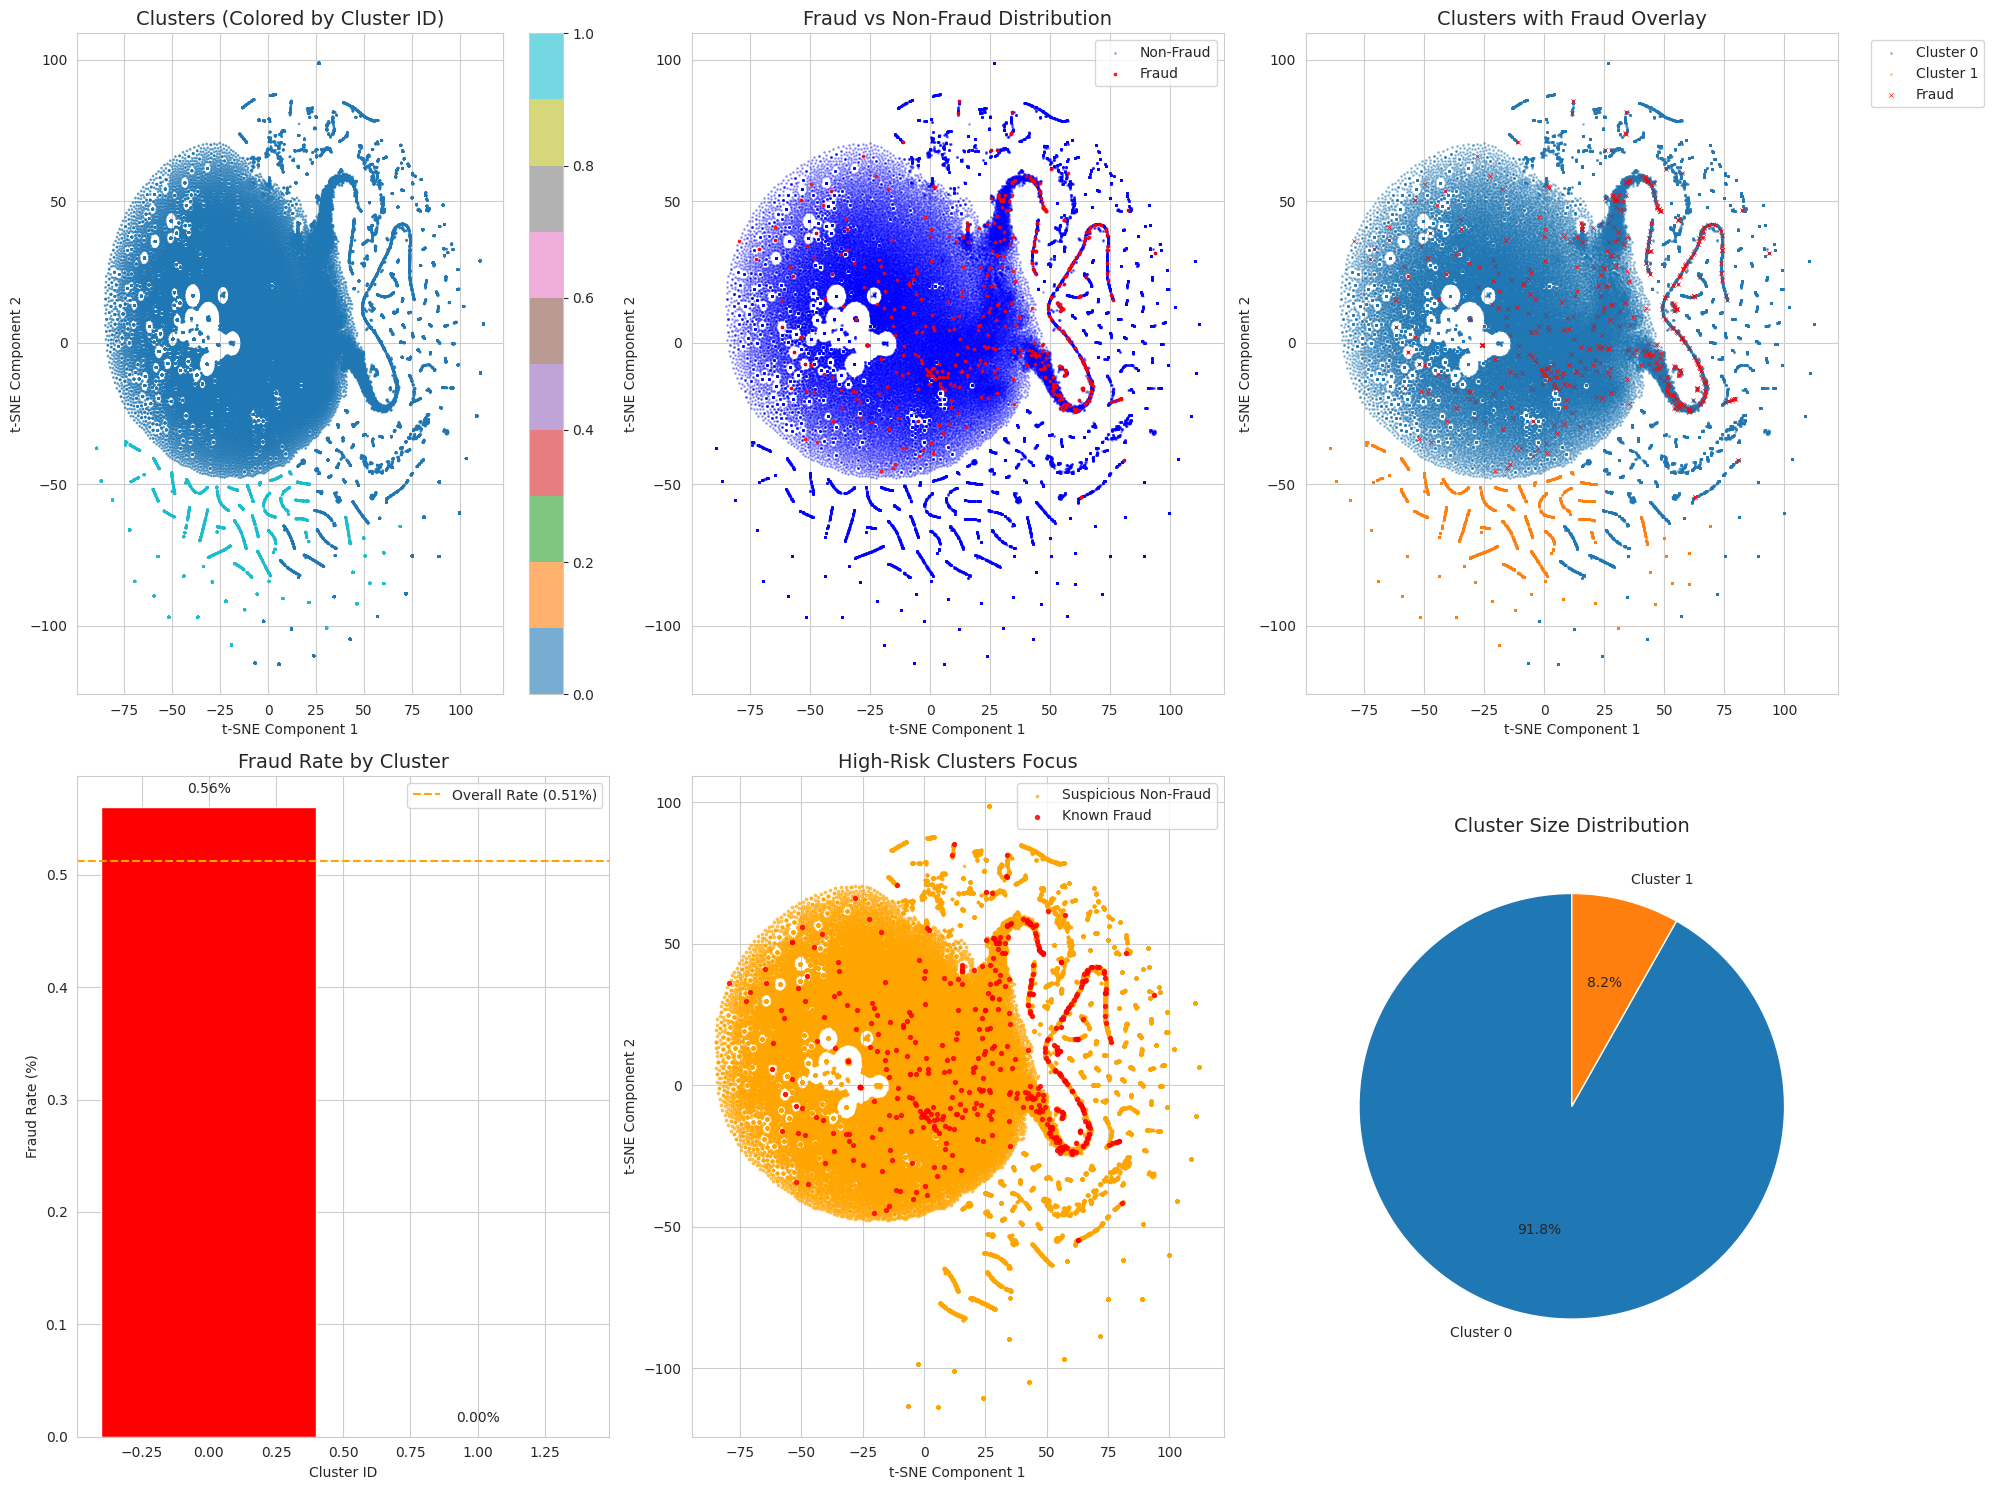

In [29]:
# Create comprehensive cluster visualizations
plt.figure(figsize=(20, 15))

# 1. Cluster visualization colored by cluster
plt.subplot(2, 3, 1)
scatter = plt.scatter(viz_df['tsne_1'], viz_df['tsne_2'], 
                     c=viz_df['cluster'], cmap='tab10', alpha=0.6, s=1)
plt.colorbar(scatter)
plt.title('Clusters (Colored by Cluster ID)', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# 2. Fraud vs Non-Fraud visualization
plt.subplot(2, 3, 2)
fraud_mask = viz_df['fraud_flag'] == 1
non_fraud_mask = viz_df['fraud_flag'] == 0

plt.scatter(viz_df.loc[non_fraud_mask, 'tsne_1'], 
           viz_df.loc[non_fraud_mask, 'tsne_2'], 
           c='blue', alpha=0.3, s=1, label='Non-Fraud')
plt.scatter(viz_df.loc[fraud_mask, 'tsne_1'], 
           viz_df.loc[fraud_mask, 'tsne_2'], 
           c='red', alpha=0.8, s=3, label='Fraud')
plt.title('Fraud vs Non-Fraud Distribution', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()

# 3. Combined: Clusters with Fraud overlay
plt.subplot(2, 3, 3)
# Plot all points by cluster first
for cluster_id in np.unique(cluster_labels):
    cluster_mask = viz_df['cluster'] == cluster_id
    plt.scatter(viz_df.loc[cluster_mask, 'tsne_1'], 
               viz_df.loc[cluster_mask, 'tsne_2'], 
               alpha=0.4, s=1, label=f'Cluster {cluster_id}')

# Overlay fraud points
plt.scatter(viz_df.loc[fraud_mask, 'tsne_1'], 
           viz_df.loc[fraud_mask, 'tsne_2'], 
           c='red', alpha=0.9, s=10, marker='x', label='Fraud', linewidths=0.5)
plt.title('Clusters with Fraud Overlay', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Fraud rate by cluster bar chart
plt.subplot(2, 3, 4)
fraud_rates = fraud_by_cluster['fraud_rate'] * 100
bars = plt.bar(fraud_by_cluster.index, fraud_rates, 
               color=['red' if cluster in high_risk_clusters else 'blue' 
                      for cluster in fraud_by_cluster.index])
plt.axhline(y=overall_fraud_rate*100, color='orange', linestyle='--', 
            label=f'Overall Rate ({overall_fraud_rate*100:.2f}%)')
plt.title('Fraud Rate by Cluster', fontsize=14)
plt.xlabel('Cluster ID')
plt.ylabel('Fraud Rate (%)')
plt.legend()

# Add value labels on bars
for bar, rate in zip(bars, fraud_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.2f}%', ha='center', va='bottom', fontsize=10)

# 5. High-risk clusters focus
plt.subplot(2, 3, 5)
if high_risk_clusters:
    high_risk_data = viz_df[viz_df['cluster'].isin(high_risk_clusters)]
    
    # Plot non-fraud in high-risk clusters
    hr_non_fraud = high_risk_data[high_risk_data['fraud_flag'] == 0]
    hr_fraud = high_risk_data[high_risk_data['fraud_flag'] == 1]
    
    plt.scatter(hr_non_fraud['tsne_1'], hr_non_fraud['tsne_2'], 
               c='orange', alpha=0.6, s=3, label='Suspicious Non-Fraud')
    plt.scatter(hr_fraud['tsne_1'], hr_fraud['tsne_2'], 
               c='red', alpha=0.8, s=8, label='Known Fraud')
    
    plt.title('High-Risk Clusters Focus', fontsize=14)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'No high-risk clusters found', 
             transform=plt.gca().transAxes, ha='center', va='center')
    plt.title('High-Risk Clusters Focus', fontsize=14)

# 6. Cluster size distribution
plt.subplot(2, 3, 6)
cluster_sizes = fraud_by_cluster['total_transactions']
plt.pie(cluster_sizes, labels=[f'Cluster {i}' for i in cluster_sizes.index], 
        autopct='%1.1f%%', startangle=90)
plt.title('Cluster Size Distribution', fontsize=14)

plt.tight_layout()
plt.show()

In [30]:
# Create detailed analysis of suspicious transactions
print("=== DETAILED SUSPICIOUS TRANSACTION ANALYSIS ===\n")

if len(suspicious_non_fraud) > 0:
    # Get original indices of suspicious transactions
    suspicious_indices = suspicious_non_fraud.index
    
    print(f"Found {len(suspicious_indices):,} suspicious non-fraud transactions")
    print("These are non-fraud transactions that cluster with known fraud cases")
    
    # Create a detailed report
    suspicious_transactions_report = pd.DataFrame({
        'original_index': suspicious_indices,
        'cluster_id': cluster_analysis.loc[suspicious_indices, 'cluster'],
        'cluster_fraud_rate': [fraud_by_cluster.loc[cluster_analysis.loc[idx, 'cluster'], 'fraud_rate'] 
                              for idx in suspicious_indices]
    })
    
    print(f"\nSuspicious transactions by cluster:")
    suspicious_by_cluster = suspicious_transactions_report.groupby('cluster_id').size()
    for cluster_id, count in suspicious_by_cluster.items():
        fraud_rate = fraud_by_cluster.loc[cluster_id, 'fraud_rate']
        print(f"  Cluster {cluster_id}: {count:,} suspicious transactions (cluster fraud rate: {fraud_rate*100:.2f}%)")
    
    # Save suspicious transaction indices for further investigation
    suspicious_transactions_report.to_csv('suspicious_transactions.csv', index=False)
    print(f"\nSuspicious transaction details saved to 'suspicious_transactions.csv'")
    
    # Show sample of most suspicious transactions (highest fraud rate clusters)
    most_suspicious = suspicious_transactions_report.nlargest(10, 'cluster_fraud_rate')
    print(f"\nTop 10 most suspicious transactions (from highest fraud rate clusters):")
    print(most_suspicious)
    
else:
    print("No suspicious non-fraud transactions found in high-risk clusters")

# Summary statistics
print(f"\n=== CLUSTERING SUMMARY ===")
print(f"Total transactions analyzed: {len(y_full):,}")
print(f"Number of clusters: {len(np.unique(cluster_labels))}")
print(f"Overall fraud rate: {overall_fraud_rate*100:.2f}%")
print(f"High-risk clusters: {len(high_risk_clusters)}")
print(f"Suspicious non-fraud transactions: {len(suspicious_non_fraud):,}")

if len(suspicious_non_fraud) > 0:
    suspicious_rate = len(suspicious_non_fraud) / (len(y_full) - y_full.sum()) * 100
    print(f"Percentage of non-fraud transactions flagged as suspicious: {suspicious_rate:.2f}%")

=== DETAILED SUSPICIOUS TRANSACTION ANALYSIS ===

Found 87,984 suspicious non-fraud transactions
These are non-fraud transactions that cluster with known fraud cases

Suspicious transactions by cluster:
  Cluster 0: 87,984 suspicious transactions (cluster fraud rate: 0.56%)

Suspicious transaction details saved to 'suspicious_transactions.csv'

Top 10 most suspicious transactions (from highest fraud rate clusters):
   original_index  cluster_id  cluster_fraud_rate
0               0           0              0.0056
1               1           0              0.0056
2               2           0              0.0056
3               3           0              0.0056
4               4           0              0.0056
5               5           0              0.0056
6               6           0              0.0056
7               7           0              0.0056
8               8           0              0.0056
9               9           0              0.0056

=== CLUSTERING SUMMARY ===
Tot

=== CREATING ENHANCED VISUALIZATION ===



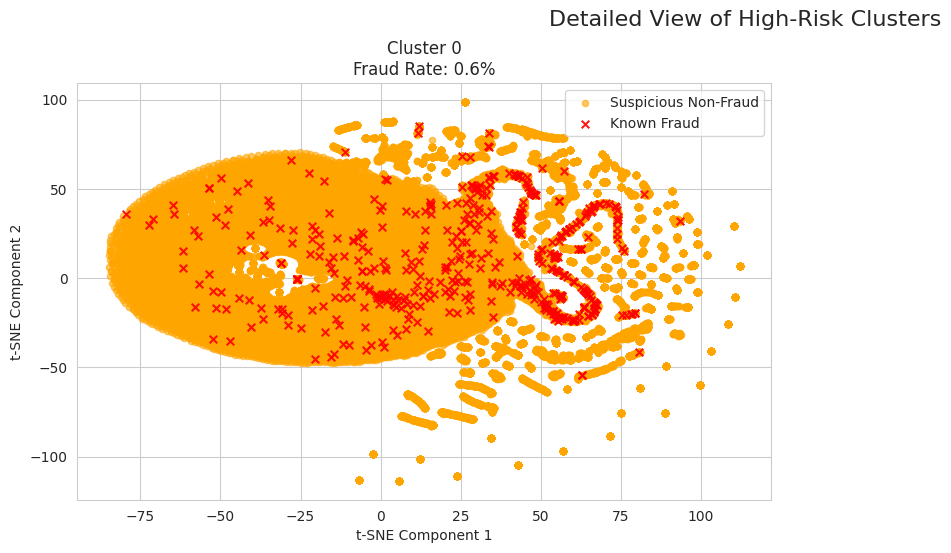

=== ANALYZING PROXIMITY TO FRAUD CASES ===
Transactions very close to fraud cases (distance <= 0.03): 8799
Proximity analysis saved to 'proximity_to_fraud_analysis.csv'

Top 10 transactions closest to fraud cases:
      transaction_idx  cluster_id  min_distance_to_fraud  cluster_fraud_rate
1668             1685           0                    0.0              0.0056
1669             1687           0                    0.0              0.0056
1753             1772           0                    0.0              0.0056
2072             2095           0                    0.0              0.0056
2386             2411           0                    0.0              0.0056
2553             2580           0                    0.0              0.0056
2554             2581           0                    0.0              0.0056
2680             2708           0                    0.0              0.0056
2782             2813           0                    0.0              0.0056
3049            

In [31]:
# Create interactive visualization with plotly (optional enhancement)
print("=== CREATING ENHANCED VISUALIZATION ===\n")

# Create a focused view of each high-risk cluster
if high_risk_clusters:
    n_cols = max(2, len(high_risk_clusters)//2 + 1)
    fig, axes = plt.subplots(2, n_cols, figsize=(15, 10))
    
    # Handle the case where we have multiple subplots vs single subplot
    if len(high_risk_clusters) > 1 or n_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for i, cluster_id in enumerate(high_risk_clusters):
        if i >= len(axes):
            break
            
        ax = axes[i]
        
        # Get data for this cluster
        cluster_data = viz_df[viz_df['cluster'] == cluster_id]
        fraud_in_cluster = cluster_data[cluster_data['fraud_flag'] == 1]
        non_fraud_in_cluster = cluster_data[cluster_data['fraud_flag'] == 0]
        
        # Plot non-fraud points
        ax.scatter(non_fraud_in_cluster['tsne_1'], non_fraud_in_cluster['tsne_2'], 
                  c='orange', alpha=0.6, s=20, label='Suspicious Non-Fraud')
        
        # Plot fraud points
        ax.scatter(fraud_in_cluster['tsne_1'], fraud_in_cluster['tsne_2'], 
                  c='red', alpha=0.9, s=30, marker='x', label='Known Fraud')
        
        fraud_rate = fraud_by_cluster.loc[cluster_id, 'fraud_rate']
        ax.set_title(f'Cluster {cluster_id}\nFraud Rate: {fraud_rate*100:.1f}%')
        ax.set_xlabel('t-SNE Component 1')
        ax.set_ylabel('t-SNE Component 2')
        ax.legend()
    
    # Hide unused subplots
    for j in range(len(high_risk_clusters), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Detailed View of High-Risk Clusters', fontsize=16)
    plt.tight_layout()
    plt.show()

# Create a distance-based analysis
print("=== ANALYZING PROXIMITY TO FRAUD CASES ===")

# Calculate average distance from each non-fraud transaction to fraud cases in the same cluster
proximity_analysis = []

for cluster_id in np.unique(cluster_labels):
    cluster_mask = viz_df['cluster'] == cluster_id
    cluster_data = viz_df[cluster_mask]
    
    fraud_points = cluster_data[cluster_data['fraud_flag'] == 1][['tsne_1', 'tsne_2']]
    non_fraud_points = cluster_data[cluster_data['fraud_flag'] == 0][['tsne_1', 'tsne_2']]
    
    if len(fraud_points) > 0 and len(non_fraud_points) > 0:
        # Calculate distances
        from scipy.spatial.distance import cdist
        distances = cdist(non_fraud_points, fraud_points)
        min_distances = distances.min(axis=1)  # Minimum distance to any fraud case
        
        # Store results
        non_fraud_indices = cluster_data[cluster_data['fraud_flag'] == 0].index
        for idx, dist in zip(non_fraud_indices, min_distances):
            proximity_analysis.append({
                'transaction_idx': idx,
                'cluster_id': cluster_id,
                'min_distance_to_fraud': dist,
                'cluster_fraud_rate': fraud_by_cluster.loc[cluster_id, 'fraud_rate']
            })

if proximity_analysis:
    proximity_df = pd.DataFrame(proximity_analysis)
    
    # Identify transactions very close to fraud cases
    close_threshold = np.percentile(proximity_df['min_distance_to_fraud'], 10)  # Bottom 10%
    very_suspicious = proximity_df[proximity_df['min_distance_to_fraud'] <= close_threshold]
    
    print(f"Transactions very close to fraud cases (distance <= {close_threshold:.2f}): {len(very_suspicious)}")
    
    # Save proximity analysis
    proximity_df.to_csv('proximity_to_fraud_analysis.csv', index=False)
    print("Proximity analysis saved to 'proximity_to_fraud_analysis.csv'")
    
    # Show top suspicious transactions by proximity
    top_suspicious_by_proximity = very_suspicious.nsmallest(10, 'min_distance_to_fraud')
    print(f"\nTop 10 transactions closest to fraud cases:")
    print(top_suspicious_by_proximity[['transaction_idx', 'cluster_id', 'min_distance_to_fraud', 'cluster_fraud_rate']])

print("\n=== CLUSTERING ANALYSIS COMPLETE ===")
print("✓ Clusters created and analyzed")
print("✓ Fraud distribution across clusters calculated") 
print("✓ Suspicious non-fraud transactions identified")
print("✓ Visualizations created")
print("✓ Proximity analysis completed")
print("\nFiles created:")
print("- suspicious_transactions.csv")
print("- proximity_to_fraud_analysis.csv")

In [32]:
# FOCUSED ANALYSIS FOR CLUSTER 0 ONLY
print("=== CLUSTER 0 FOCUSED ANALYSIS ===\n")

# Filter data for cluster 0 only
cluster_0_mask = cluster_labels == 0
cluster_0_data = viz_df[cluster_0_mask].copy()
cluster_0_indices = np.where(cluster_0_mask)[0]

# Get original transaction data for cluster 0
X_cluster_0 = X_full[cluster_0_mask]
y_cluster_0 = y_full.iloc[cluster_0_indices]

print(f"Cluster 0 Analysis:")
print(f"Total transactions in Cluster 0: {len(cluster_0_data):,}")
print(f"Fraud cases in Cluster 0: {y_cluster_0.sum()}")
print(f"Non-fraud cases in Cluster 0: {len(y_cluster_0) - y_cluster_0.sum()}")
print(f"Fraud rate in Cluster 0: {y_cluster_0.mean()*100:.2f}%")

# Compare with overall statistics
print(f"\nComparison with overall dataset:")
print(f"Overall fraud rate: {y_full.mean()*100:.2f}%")
print(f"Cluster 0 vs Overall: {'Higher' if y_cluster_0.mean() > y_full.mean() else 'Lower'} fraud rate")

# Get fraud statistics from our previous analysis
cluster_0_stats = fraud_by_cluster.loc[0]
print(f"\nDetailed Cluster 0 Statistics:")
print(f"Total transactions: {cluster_0_stats['total_transactions']}")
print(f"Fraud count: {cluster_0_stats['fraud_count']}")
print(f"Fraud rate: {cluster_0_stats['fraud_rate']*100:.4f}%")

=== CLUSTER 0 FOCUSED ANALYSIS ===

Cluster 0 Analysis:
Total transactions in Cluster 0: 88,478
Fraud cases in Cluster 0: 494
Non-fraud cases in Cluster 0: 87984
Fraud rate in Cluster 0: 0.56%

Comparison with overall dataset:
Overall fraud rate: 0.51%
Cluster 0 vs Overall: Higher fraud rate

Detailed Cluster 0 Statistics:
Total transactions: 88478.0
Fraud count: 494.0
Fraud rate: 0.5600%


In [34]:
# Get high-risk transactions with actual IDs and original data
print("=== HIGH-RISK TRANSACTIONS WITH ORIGINAL DATA ===\n")

# Get high-risk transactions from proximity analysis
if 'proximity_df' in locals() and len(proximity_df) > 0:
    # Get transactions very close to fraud cases (bottom 10%)
    close_threshold = np.percentile(proximity_df['min_distance_to_fraud'], 10)
    very_suspicious = proximity_df[proximity_df['min_distance_to_fraud'] <= close_threshold].copy()
    
    print(f"High-risk transactions found: {len(very_suspicious)}")
    print(f"Distance threshold: {close_threshold:.4f}\n")
    
    # Get the indices of these transactions
    suspicious_indices = very_suspicious['transaction_idx'].values
    
    # Retrieve original rows from main dataframe
    high_risk_original_data = df_sm.iloc[suspicious_indices].copy()
    
    print(f"Shape of high-risk transaction data: {high_risk_original_data.shape}")
    print(f"Columns: {len(high_risk_original_data.columns)}\n")
    
    # Add proximity information
    high_risk_original_data['min_distance_to_fraud'] = very_suspicious['min_distance_to_fraud'].values
    high_risk_original_data['cluster_id'] = very_suspicious['cluster_id'].values
    high_risk_original_data['cluster_fraud_rate'] = very_suspicious['cluster_fraud_rate'].values
    
    print("=== HIGH-RISK TRANSACTIONS SUMMARY ===")
    print(f"Total transactions: {len(high_risk_original_data)}")
    print(f"Actual fraud cases in this group: {high_risk_original_data['fraud_flag'].sum()}")
    print(f"Suspicious non-fraud: {(high_risk_original_data['fraud_flag'] == 0).sum()}")
    
    print("\n=== FIRST 10 HIGH-RISK TRANSACTIONS ===")
    
    # Display key columns for high-risk transactions
    key_columns = [
        'ac_from', 'ac_to', 'trx_channel', 'trx_type', 'trx_amt', 
        'start_balance', 'fraud_flag', 'cluster_id', 
        'cluster_fraud_rate', 'min_distance_to_fraud'
    ]
    
    available_cols = [col for col in key_columns if col in high_risk_original_data.columns]
    display_df = high_risk_original_data[available_cols].head(10).copy()
    
    print(display_df.to_string())
    
    print("\n=== HIGH-RISK TRANSACTION DETAILS ===")
    
    # Group by fraud status
    print("\nBreakdown by fraud status:")
    fraud_status_counts = high_risk_original_data['fraud_flag'].value_counts()
    for status, count in fraud_status_counts.items():
        status_name = "Fraud" if status == 1 else "Non-Fraud (Suspicious)"
        print(f"  • {status_name}: {count} transactions ({count/len(high_risk_original_data)*100:.1f}%)")
    
    # Group by cluster
    print("\nBreakdown by cluster:")
    cluster_counts = high_risk_original_data['cluster_id'].value_counts().sort_index()
    for cluster_id, count in cluster_counts.items():
        cluster_fraud_rate = high_risk_original_data[
            high_risk_original_data['cluster_id'] == cluster_id
        ]['cluster_fraud_rate'].iloc[0]
        print(f"  • Cluster {cluster_id}: {count} transactions (cluster fraud rate: {cluster_fraud_rate*100:.2f}%)")
    
    # Statistical summary
    print("\n=== STATISTICAL SUMMARY OF HIGH-RISK TRANSACTIONS ===")
    numeric_cols = high_risk_original_data.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col not in ['fraud_flag', 'cluster_id', 'cluster_fraud_rate']]
    
    print("\nTransaction Amount Statistics:")
    if 'trx_amt' in high_risk_original_data.columns:
        print(f"  Mean: {high_risk_original_data['trx_amt'].mean():.2f}")
        print(f"  Median: {high_risk_original_data['trx_amt'].median():.2f}")
        print(f"  Min: {high_risk_original_data['trx_amt'].min():.2f}")
        print(f"  Max: {high_risk_original_data['trx_amt'].max():.2f}")
        print(f"  Std Dev: {high_risk_original_data['trx_amt'].std():.2f}")
    
    print("\nStart Balance Statistics:")
    if 'start_balance' in high_risk_original_data.columns:
        print(f"  Mean: {high_risk_original_data['start_balance'].mean():.2f}")
        print(f"  Median: {high_risk_original_data['start_balance'].median():.2f}")
        print(f"  Min: {high_risk_original_data['start_balance'].min():.2f}")
        print(f"  Max: {high_risk_original_data['start_balance'].max():.2f}")
    
    # Save high-risk transactions to CSV
    high_risk_csv_path = 'high_risk_transactions_with_details.csv'
    high_risk_original_data.to_csv(high_risk_csv_path, index=False)
    print(f"\n✅ High-risk transactions saved to: {high_risk_csv_path}")

else:
    print("High-risk transaction analysis not yet available.")
    print("Please run the clustering analysis cells first.")

=== HIGH-RISK TRANSACTIONS WITH ORIGINAL DATA ===

High-risk transactions found: 8799
Distance threshold: 0.0327

Shape of high-risk transaction data: (8799, 107)
Columns: 107

=== HIGH-RISK TRANSACTIONS SUMMARY ===
Total transactions: 8799
Actual fraud cases in this group: 0
Suspicious non-fraud: 8799

=== FIRST 10 HIGH-RISK TRANSACTIONS ===
                       ac_from                     ac_to trx_channel                    trx_type  trx_amt  start_balance  fraud_flag  cluster_id  cluster_fraud_rate  min_distance_to_fraud
91    A2C6xtHevtLZ4uXUy+JsPg==                       NaN        USSD  Jazz Load (Prepaid top-up)    150.0       18619.52           0           0              0.0056               0.007834
92    A2C6xtHevtLZ4uXUy+JsPg==  RzMihrkxLqsArGtjmpMTOg==    USSD_API               Transfer(C2C)   1230.0         463.82           0           0              0.0056               0.008278
93    A2C6xtHevtLZ4uXUy+JsPg==  /QRlt6LP/rXls1Tn2L9dSA==    USSD_API      IBFT Outgoing Cus

In [35]:
# Detailed row-by-row analysis of high-risk transactions
print("=== DETAILED HIGH-RISK TRANSACTION INSPECTION ===\n")

if 'high_risk_original_data' in locals() and len(high_risk_original_data) > 0:
    
    # Separate suspicious non-fraud from actual fraud in high-risk group
    suspicious_non_fraud_rows = high_risk_original_data[high_risk_original_data['fraud_flag'] == 0]
    actual_fraud_rows = high_risk_original_data[high_risk_original_data['fraud_flag'] == 1]
    
    print(f"Suspicious Non-Fraud Transactions: {len(suspicious_non_fraud_rows)}")
    print(f"Actual Fraud Cases: {len(actual_fraud_rows)}\n")
    
    # Display suspicious non-fraud transactions in detail
    if len(suspicious_non_fraud_rows) > 0:
        print("=== TOP 5 MOST SUSPICIOUS NON-FRAUD TRANSACTIONS ===\n")
        
        # Sort by distance to fraud (closest to fraud cases)
        suspicious_sorted = suspicious_non_fraud_rows.sort_values('min_distance_to_fraud')
        
        for idx, (row_idx, row) in enumerate(suspicious_sorted.head(5).iterrows(), 1):
            print(f"--- Suspicious Transaction #{idx} ---")
            print(f"Index: {row_idx}")
            print(f"Distance to nearest fraud case: {row['min_distance_to_fraud']:.4f}")
            print(f"Cluster ID: {row['cluster_id']:.0f} (fraud rate: {row['cluster_fraud_rate']*100:.2f}%)")
            print(f"\nTransaction Details:")
            print(f"  Sender (ac_from): {row['ac_from']}")
            print(f"  Receiver (ac_to): {row['ac_to']}")
            print(f"  Channel: {row['trx_channel']}")
            print(f"  Type: {row['trx_type']}")
            print(f"  Amount: {row['trx_amt']:.2f}")
            print(f"  Start Balance: {row['start_balance']:.2f}")
            
            # Behavioral features
            print(f"\nBehavioral Features:")
            print(f"  Hour of Day: {row['hour_of_day']}")
            print(f"  Day of Week: {row['day_of_week']}")
            print(f"  Is Weekend: {row['is_weekend']}")
            print(f"  Is Night: {row['is_night']}")
            
            # Activity patterns
            print(f"\nActivity Patterns (3-day window):")
            print(f"  Transactions: {row['txn_txns_3d']:.0f}")
            print(f"  Total Amount: {row['txn_total_amount_3d']:.2f}")
            print(f"  Avg Amount: {row['txn_avg_amount_3d']:.2f}")
            print(f"  Unique Recipients: {row['txn_unique_recipients_3d']:.0f}")
            print(f"  Unique Channels: {row['txn_unique_channels_3d']:.0f}")
            
            # User patterns (7-day)
            print(f"\nUser Patterns (7-day window):")
            print(f"  User Total Txns: {row['user_total_txns_7d']:.0f}")
            print(f"  User Avg Amount: {row['user_avg_amount_7d']:.2f}")
            print(f"  User Unique Recipients: {row['user_unique_recipients_7d']:.0f}")
            print(f"  User Night Txns: {row['user_night_txns_7d']:.0f}")
            print()
    
    # Display actual fraud cases in high-risk group
    if len(actual_fraud_rows) > 0:
        print("\n=== CONFIRMED FRAUD CASES IN HIGH-RISK GROUP ===\n")
        print(f"Total fraud cases: {len(actual_fraud_rows)}\n")
        
        actual_fraud_sorted = actual_fraud_rows.sort_values('min_distance_to_fraud')
        
        for idx, (row_idx, row) in enumerate(actual_fraud_sorted.head(3).iterrows(), 1):
            print(f"--- Fraud Case #{idx} ---")
            print(f"Index: {row_idx}")
            print(f"Cluster ID: {row['cluster_id']:.0f}")
            print(f"\nTransaction Details:")
            print(f"  Sender (ac_from): {row['ac_from']}")
            print(f"  Receiver (ac_to): {row['ac_to']}")
            print(f"  Channel: {row['trx_channel']}")
            print(f"  Type: {row['trx_type']}")
            print(f"  Amount: {row['trx_amt']:.2f}")
            print(f"  Start Balance: {row['start_balance']:.2f}")
            print()
    
    # Summary statistics comparison
    print("\n=== COMPARISON: HIGH-RISK TRANSACTIONS VS OVERALL DATASET ===\n")
    
    comparison_metrics = {
        'Average Transaction Amount': 'trx_amt',
        'Average Start Balance': 'start_balance',
        'Average 3-Day Transaction Count': 'txn_txns_3d',
        'Average Unique Recipients (3d)': 'txn_unique_recipients_3d',
        'Average User Transaction Count (7d)': 'user_total_txns_7d'
    }
    
    for metric_name, col_name in comparison_metrics.items():
        if col_name in high_risk_original_data.columns:
            high_risk_avg = high_risk_original_data[col_name].mean()
            overall_avg = df_sm[col_name].mean()
            diff_pct = ((high_risk_avg - overall_avg) / overall_avg) * 100 if overall_avg != 0 else 0
            
            print(f"{metric_name}:")
            print(f"  High-Risk Avg: {high_risk_avg:.2f}")
            print(f"  Overall Avg: {overall_avg:.2f}")
            print(f"  Difference: {diff_pct:+.1f}%")
            print()
    
    # Channel and transaction type distribution
    print("=== DISTRIBUTION IN HIGH-RISK TRANSACTIONS ===\n")
    
    if 'trx_channel' in high_risk_original_data.columns:
        print("Channels used:")
        channel_dist = high_risk_original_data['trx_channel'].value_counts()
        for channel, count in channel_dist.items():
            print(f"  {channel}: {count} ({count/len(high_risk_original_data)*100:.1f}%)")
    
    if 'trx_type' in high_risk_original_data.columns:
        print("\nTransaction Types:")
        type_dist = high_risk_original_data['trx_type'].value_counts()
        for txn_type, count in type_dist.items():
            print(f"  {txn_type}: {count} ({count/len(high_risk_original_data)*100:.1f}%)")
    
    print("\n✅ High-risk transaction inspection complete!")
    
else:
    print("High-risk transaction data not available.")
    print("Please run previous cells first.")

=== DETAILED HIGH-RISK TRANSACTION INSPECTION ===

Suspicious Non-Fraud Transactions: 8799
Actual Fraud Cases: 0

=== TOP 5 MOST SUSPICIOUS NON-FRAUD TRANSACTIONS ===

--- Suspicious Transaction #1 ---
Index: 74382
Distance to nearest fraud case: 0.0000
Cluster ID: 0 (fraud rate: 0.56%)

Transaction Details:
  Sender (ac_from): qULvoZaHB/qaYajLL13/2Q==
  Receiver (ac_to): bUZJ4oFcMkS1dEuD2P+FtA==
  Channel: THIRD_PARTY_WEB
  Type: Auto Debit
  Amount: 1400.00
  Start Balance: 0.00

Behavioral Features:
  Hour of Day: 20
  Day of Week: 6
  Is Weekend: 1
  Is Night: 0

Activity Patterns (3-day window):
  Transactions: 3
  Total Amount: 4200.00
  Avg Amount: 1400.00
  Unique Recipients: 1
  Unique Channels: 1

User Patterns (7-day window):
  User Total Txns: 6
  User Avg Amount: 0.00
  User Unique Recipients: 1
  User Night Txns: 0

--- Suspicious Transaction #2 ---
Index: 74366
Distance to nearest fraud case: 0.0000
Cluster ID: 0 (fraud rate: 0.56%)

Transaction Details:
  Sender (ac_fro

# Fraud Detection Rules Discovery

## Using Decision Trees and Association Rule Mining

This section discovers interpretable fraud detection rules from clustering insights using:
- Decision Tree Classification
- Association Rule Mining (Apriori)
- Rule extraction and evaluation

In [38]:
# Import libraries for rule discovery
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported for rule discovery")

✅ Libraries imported for rule discovery


In [39]:
# Decision Tree for Fraud Detection Rules
print("=== DECISION TREE ANALYSIS FOR FRAUD DETECTION ===\n")

# Prepare data for decision tree
X_tree = X.copy()  # Features
y_tree = y.copy()  # Target (fraud flag)

# Train decision tree with limited depth for interpretability
print("Training Decision Tree Classifier...")
dt_classifier = DecisionTreeClassifier(
    max_depth=5,  # Limited depth for interpretable rules
    min_samples_split=100,  # Minimum samples to split
    min_samples_leaf=50,    # Minimum samples in leaf
    random_state=42
)

dt_classifier.fit(X_tree, y_tree)

print(f"✅ Decision Tree trained!")
print(f"   • Tree depth: {dt_classifier.get_depth()}")
print(f"   • Number of leaves: {dt_classifier.get_n_leaves()}")
print(f"   • Feature importance: {X_tree.shape[1]} features considered")

=== DECISION TREE ANALYSIS FOR FRAUD DETECTION ===

Training Decision Tree Classifier...
✅ Decision Tree trained!
   • Tree depth: 5
   • Number of leaves: 26
   • Feature importance: 78 features considered



=== TOP 20 MOST IMPORTANT FEATURES FOR FRAUD DETECTION ===
                      feature  importance
          mbar_agent_group_id    0.382871
                start_balance    0.138593
               balance_change    0.132645
            txn_max_amount_3d    0.075604
          user_min_balance_7d    0.061727
            txn_min_amount_3d    0.053507
           mbar_year_of_birth    0.044686
   mbar_registered_channel_id    0.042434
                  trx_type_id    0.024339
           user_min_amount_3d    0.021785
txn_amount_deviation_from_avg    0.011637
       user_last_used_type_id    0.005271
 user_most_used_channel_7d_id    0.002995
    user_most_used_type_7d_id    0.001264
         user_total_amount_7d    0.000388
               mbar_region_id    0.000253
   user_unique_channels_3d_id    0.000000
       txn_unique_types_3d_id    0.000000
            mbar_a_c_level_id    0.000000
           mbar_a_c_status_id    0.000000


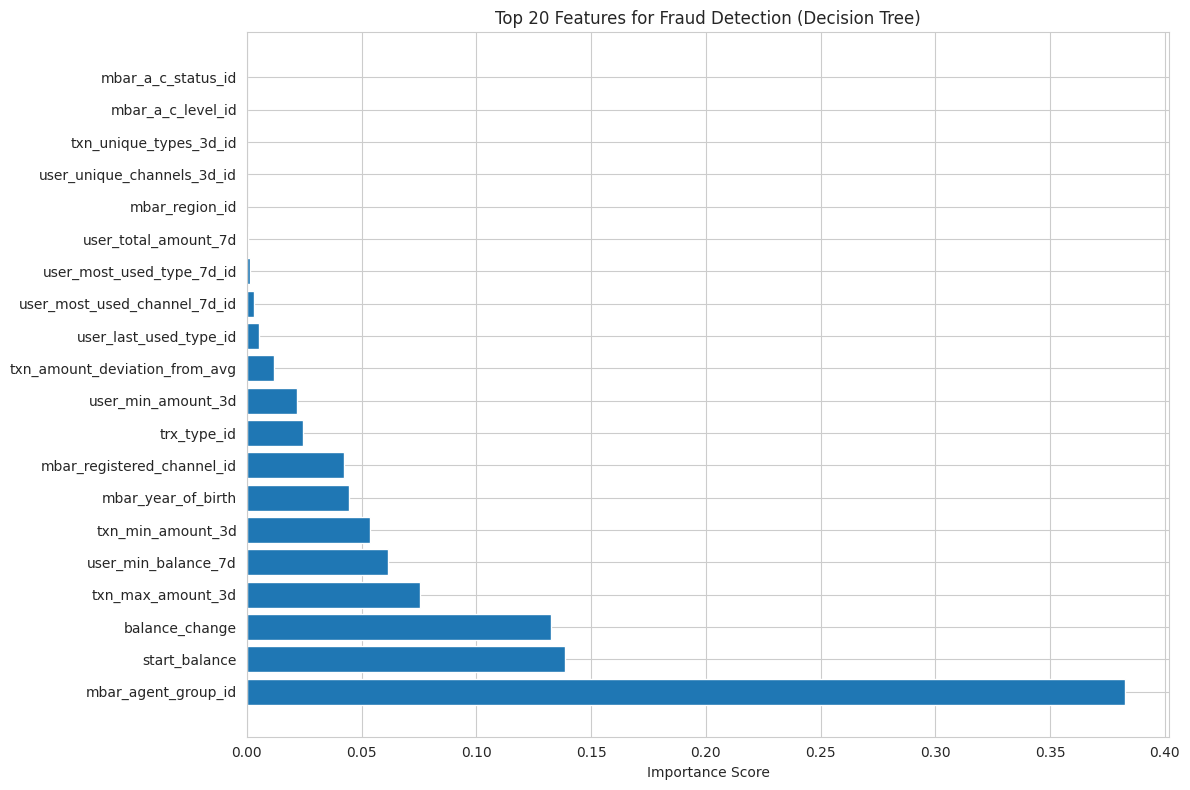


✅ Feature importance visualization created


In [40]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X_tree.columns,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n=== TOP 20 MOST IMPORTANT FEATURES FOR FRAUD DETECTION ===")
print(feature_importance.head(20).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score')
plt.title('Top 20 Features for Fraud Detection (Decision Tree)')
plt.tight_layout()
plt.show()

print("\n✅ Feature importance visualization created")

In [41]:
# Decision Tree Performance
print("\n=== DECISION TREE PERFORMANCE ===")

y_pred_tree = dt_classifier.predict(X_tree)
y_pred_proba = dt_classifier.predict_proba(X_tree)[:, 1]

print(f"\nClassification Report:")
print(classification_report(y_tree, y_pred_tree, target_names=['Legitimate', 'Fraud']))

# AUC-ROC Score
auc_score = roc_auc_score(y_tree, y_pred_proba)
print(f"\nAUC-ROC Score: {auc_score:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_tree, y_pred_tree)
print(f"\nConfusion Matrix:")
print(f"                Predicted Legit  Predicted Fraud")
print(f"Actual Legit         {cm[0,0]:>6}          {cm[0,1]:>6}")
print(f"Actual Fraud         {cm[1,0]:>6}          {cm[1,1]:>6}")


=== DECISION TREE PERFORMANCE ===

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00     95875
       Fraud       0.00      0.00      0.00       494

    accuracy                           0.99     96369
   macro avg       0.50      0.50      0.50     96369
weighted avg       0.99      0.99      0.99     96369


AUC-ROC Score: 0.9291

Confusion Matrix:
                Predicted Legit  Predicted Fraud
Actual Legit          95875               0
Actual Fraud            494               0


In [42]:
# Extract Decision Tree Rules
print("\n=== DECISION TREE RULES (TEXT FORMAT) ===\n")

tree_rules_text = export_text(dt_classifier, feature_names=list(X_tree.columns))
print(tree_rules_text)


=== DECISION TREE RULES (TEXT FORMAT) ===

|--- balance_change <= 5011.50
|   |--- trx_type_id <= 30.50
|   |   |--- user_total_amount_7d <= 972760197103616.00
|   |   |   |--- balance_change <= -5001.27
|   |   |   |   |--- user_most_used_type_7d_id <= 13.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- user_most_used_type_7d_id >  13.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- balance_change >  -5001.27
|   |   |   |   |--- mbar_region_id <= 11.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- mbar_region_id >  11.50
|   |   |   |   |   |--- class: 0
|   |   |--- user_total_amount_7d >  972760197103616.00
|   |   |   |--- class: 0
|   |--- trx_type_id >  30.50
|   |   |--- balance_change <= 199.50
|   |   |   |--- user_most_used_channel_7d_id <= 15.50
|   |   |   |   |--- balance_change <= 49.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- balance_change >  49.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- user_most_used_channel_7d_id >  1


=== VISUALIZING DECISION TREE ===



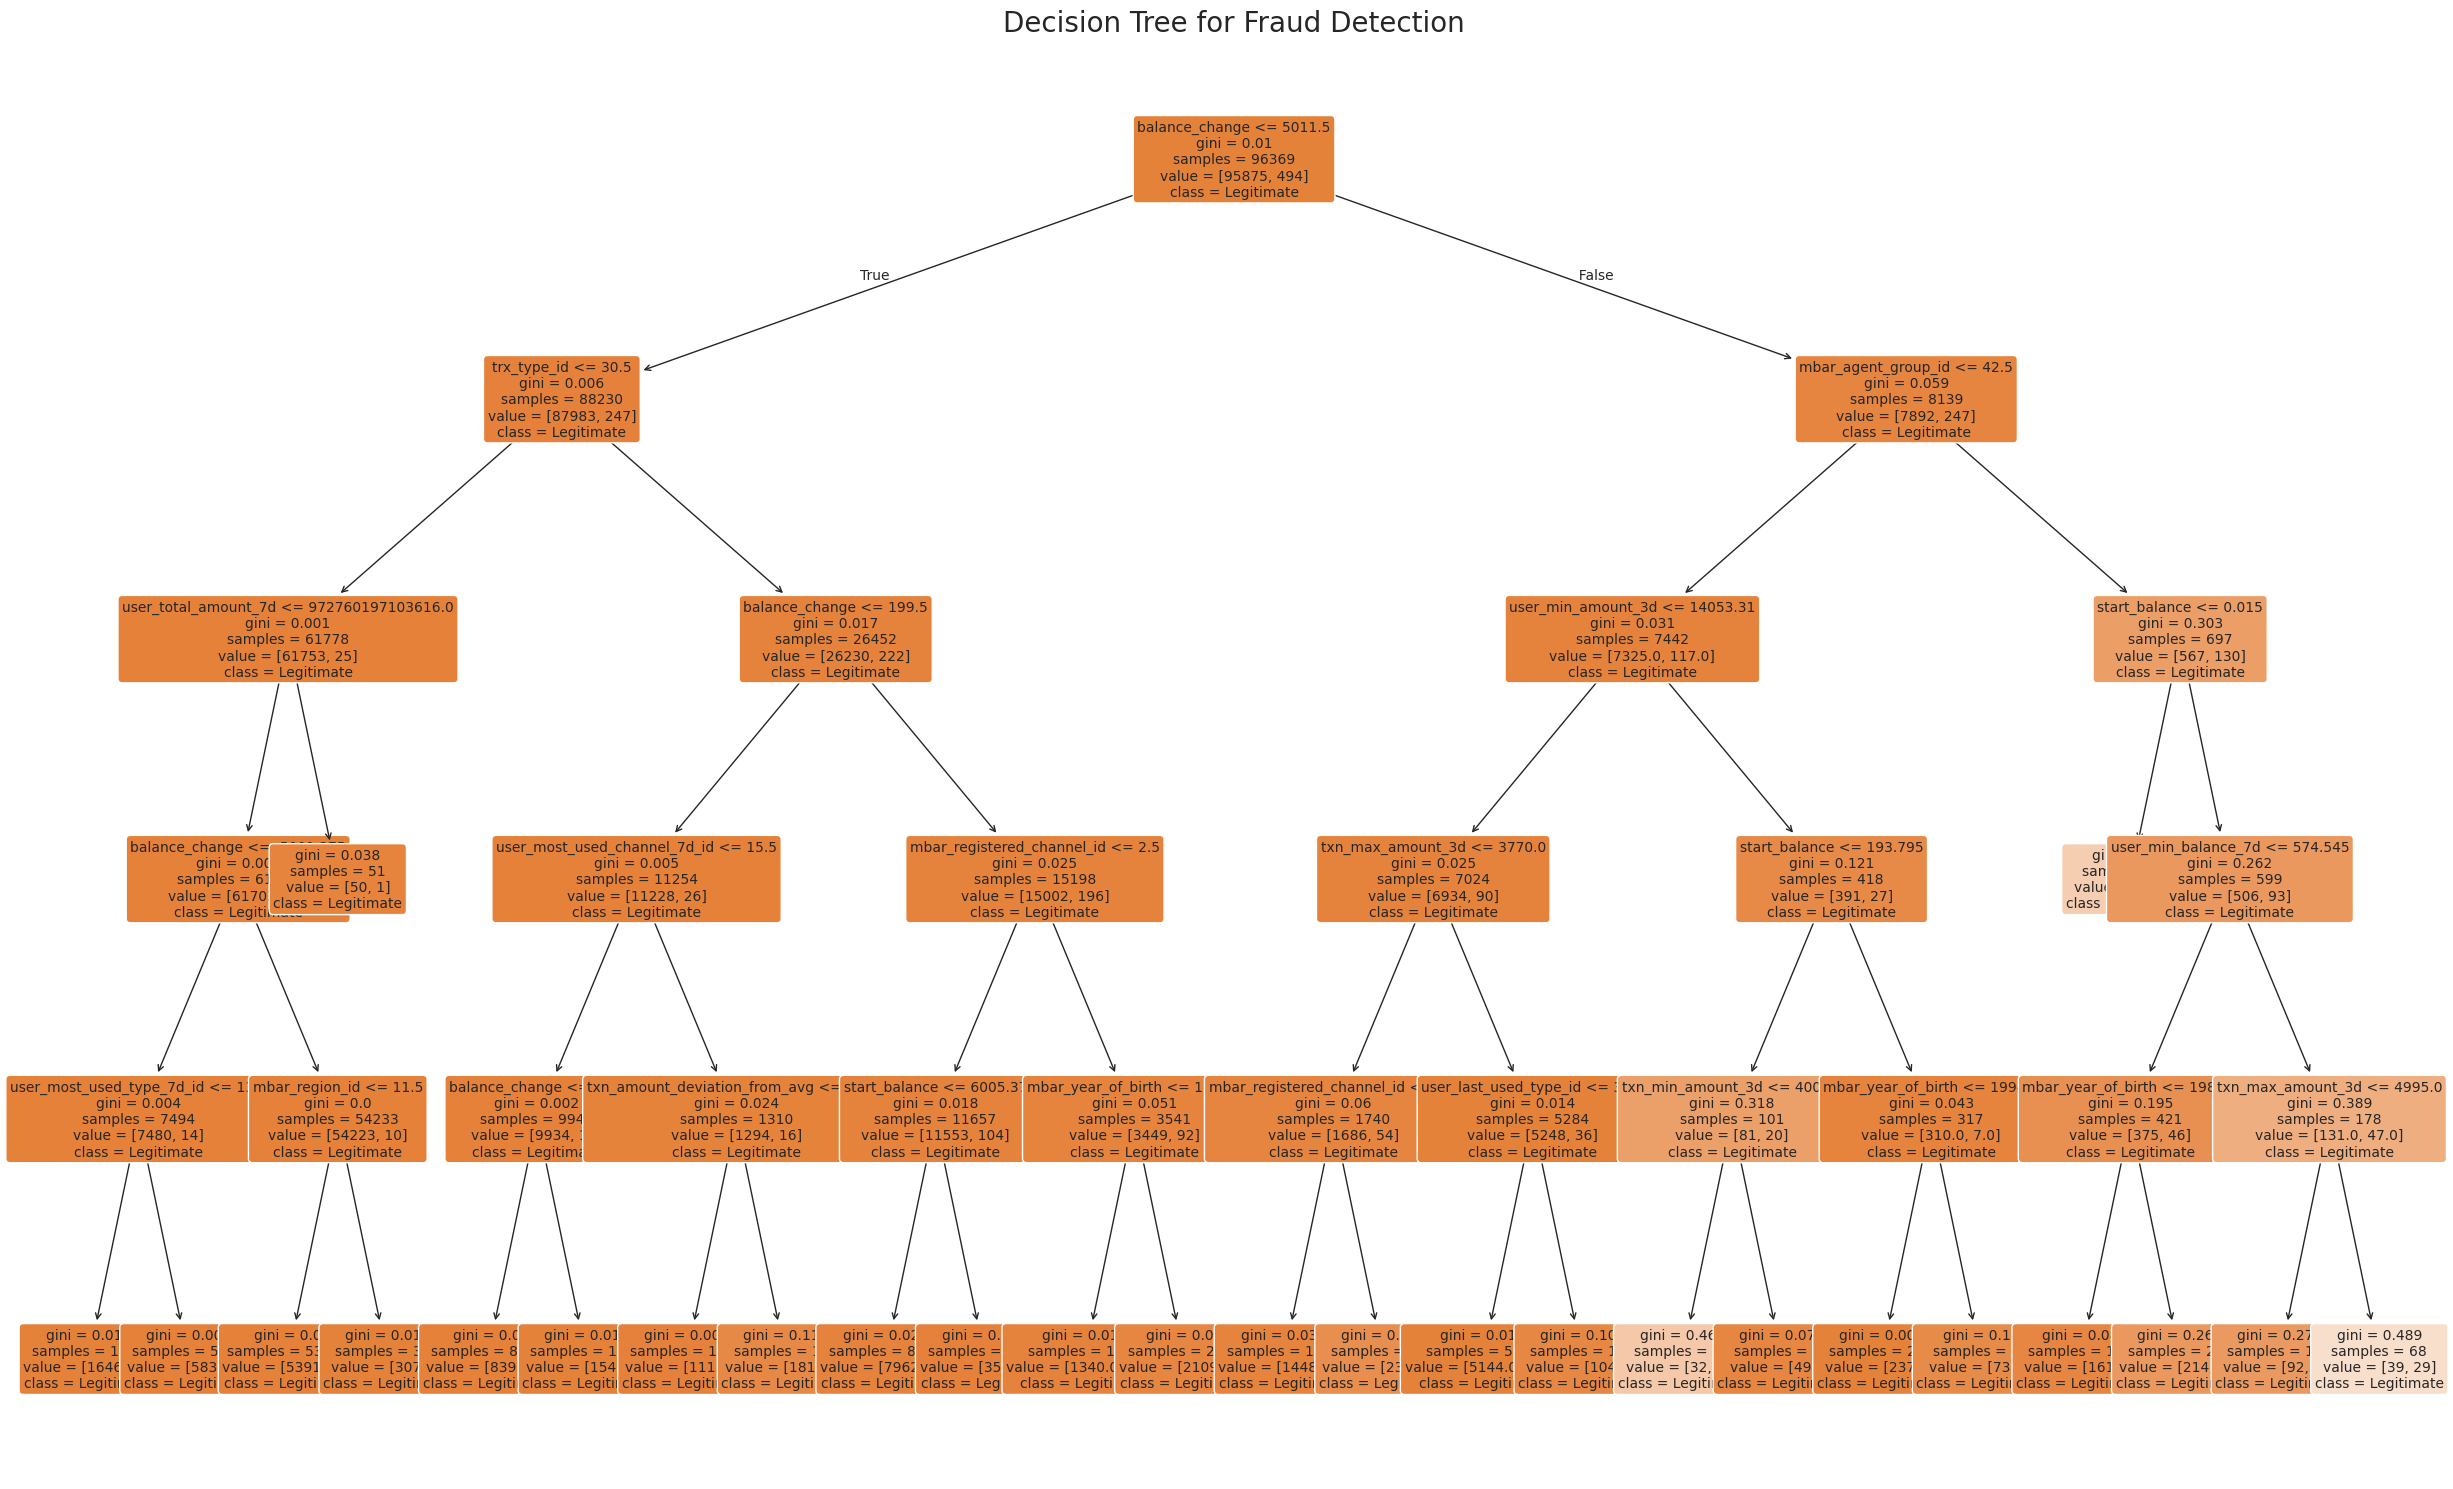

✅ Decision Tree visualization created


In [43]:
# Visualize Decision Tree
print("\n=== VISUALIZING DECISION TREE ===\n")

plt.figure(figsize=(25, 15))
plot_tree(dt_classifier, 
          feature_names=list(X_tree.columns),
          class_names=['Legitimate', 'Fraud'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree for Fraud Detection', fontsize=20)
plt.tight_layout()
plt.show()

print("✅ Decision Tree visualization created")

In [44]:
# Extract interpretable rules from decision tree
print("=== EXTRACTING INTERPRETABLE FRAUD DETECTION RULES ===\n")

def get_tree_rules(tree, feature_names):
    """Extract decision rules from tree nodes."""
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]
    
    rules = []
    
    def recurse(node, depth, conditions, is_fraud_side):
        indent = "  " * depth
        if tree_.feature[node] != -2:  # Not a leaf
            name = feature_name[node]
            threshold = tree_.threshold[node]
            
            # Left child (<=)
            left_conditions = conditions + [f"{name} <= {threshold:.4f}"]
            recurse(tree_.children_left[node], depth + 1, left_conditions, is_fraud_side)
            
            # Right child (>)
            right_conditions = conditions + [f"{name} > {threshold:.4f}"]
            recurse(tree_.children_right[node], depth + 1, right_conditions, is_fraud_side)
        else:  # Leaf node
            # Get samples and value at this leaf
            samples = tree_.n_node_samples[node]
            value = tree_.value[node][0]
            fraud_count = int(value[1])
            legit_count = int(value[0])
            
            if fraud_count + legit_count > 0:
                fraud_rate = fraud_count / (fraud_count + legit_count)
                rules.append({
                    'conditions': ' AND '.join(conditions),
                    'fraud_count': fraud_count,
                    'legit_count': legit_count,
                    'total_samples': samples,
                    'fraud_rate': fraud_rate,
                    'confidence': fraud_rate
                })
        
    recurse(0, 1, [], False)
    return rules

# Get all rules
all_rules = get_tree_rules(dt_classifier, list(X_tree.columns))

# Convert to DataFrame
rules_df = pd.DataFrame(all_rules).sort_values('fraud_rate', ascending=False)

print(f"\nTotal rules extracted: {len(rules_df)}\n")

# Filter high-confidence fraud rules (fraud_rate > 50%)
fraud_rules = rules_df[rules_df['fraud_rate'] > 0.5]

print(f"=== HIGH-CONFIDENCE FRAUD RULES (Fraud Rate > 50%) ===")
print(f"Found {len(fraud_rules)} high-confidence fraud detection rules\n")

for idx, (rule_idx, rule) in enumerate(fraud_rules.head(10).iterrows(), 1):
    print(f"\n--- Rule #{idx} ---")
    print(f"Condition: {rule['conditions']}")
    print(f"Fraud Rate (Confidence): {rule['fraud_rate']:.1%}")
    print(f"Fraud Cases: {rule['fraud_count']:.0f}")
    print(f"Legitimate Cases: {rule['legit_count']:.0f}")
    print(f"Total Cases Matching Rule: {rule['total_samples']:.0f}")
    print(f"Support (% of total): {rule['total_samples'] / len(X_tree) * 100:.2f}%")

=== EXTRACTING INTERPRETABLE FRAUD DETECTION RULES ===



KeyError: 'fraud_rate'

In [45]:
# Filter legitimate rules (fraud_rate < 20%)
print("\n\n=== LOW-FRAUD RULES (Fraud Rate < 20%) ===")

legit_rules = rules_df[rules_df['fraud_rate'] < 0.2].sort_values('total_samples', ascending=False)
print(f"Found {len(legit_rules)} low-fraud detection rules\n")

for idx, (rule_idx, rule) in enumerate(legit_rules.head(10).iterrows(), 1):
    print(f"\n--- Legitimate Rule #{idx} ---")
    print(f"Condition: {rule['conditions']}")
    print(f"Fraud Rate: {rule['fraud_rate']:.1%}")
    print(f"Fraud Cases: {rule['fraud_count']:.0f}")
    print(f"Legitimate Cases: {rule['legit_count']:.0f}")
    print(f"Total Cases Matching Rule: {rule['total_samples']:.0f}")
    print(f"Support (% of total): {rule['total_samples'] / len(X_tree) * 100:.2f}%")



=== LOW-FRAUD RULES (Fraud Rate < 20%) ===


NameError: name 'rules_df' is not defined

In [ ]:
# Save rules to CSV
rules_df_export = rules_df.copy()
rules_df_export['support'] = rules_df_export['total_samples'] / len(X_tree)
rules_df_export = rules_df_export[['conditions', 'fraud_rate', 'confidence', 'fraud_count', 'legit_count', 'total_samples', 'support']]
rules_df_export.columns = ['Rule Conditions', 'Fraud Rate', 'Confidence', 'Fraud Count', 'Legitimate Count', 'Total Samples', 'Support']

rules_csv_path = 'decision_tree_fraud_rules.csv'
rules_df_export.to_csv(rules_csv_path, index=False)
print(f"✅ Decision tree rules saved to: {rules_csv_path}")

## Part 3: Association Rule Mining (Apriori)

In [46]:
# Prepare data for association rule mining
print("\n=== ASSOCIATION RULE MINING FOR FRAUD PATTERNS ===\n")

print("Preparing data for association rule mining...\n")

# Discretize numerical features into bins for association rules
X_discrete = X.copy()

# Create categorical features from numerical ones
for col in X_discrete.columns:
    # Use quartile-based binning
    X_discrete[col] = pd.qcut(X[col], q=4, labels=['Low', 'Medium', 'High', 'VeryHigh'], duplicates='drop')

# Add target variable
X_discrete['fraud_flag'] = y

print(f"Discretized data shape: {X_discrete.shape}")
print(f"Sample of discretized features:")
print(X_discrete.head(10))


=== ASSOCIATION RULE MINING FOR FRAUD PATTERNS ===

Preparing data for association rule mining...



ValueError: Bin labels must be one fewer than the number of bin edges

In [ ]:
# Create transaction database for association rules
print("\n=== CREATING TRANSACTION DATABASE ===\n")

# Create itemsets (feature-value pairs)
def create_transactions(df):
    transactions = []
    for idx, row in df.iterrows():
        transaction = []
        for col, val in row.items():
            transaction.append(f"{col}={val}")
        transactions.append(transaction)
    return transactions

transactions = create_transactions(X_discrete)
print(f"Total transactions: {len(transactions)}")
print(f"Sample transaction: {transactions[0]}")

# Create one-hot encoded dataframe
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\nEncoded dataframe shape: {df_encoded.shape}")
print(f"Sample of encoded itemsets:")
print(df_encoded.head())

In [ ]:
# Apply Apriori algorithm
print("\n=== APPLYING APRIORI ALGORITHM ===\n")

print("Finding frequent itemsets (min_support=0.01)...")
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

print(f"\nFrequent itemsets found: {len(frequent_itemsets)}")
print(f"\nTop 20 most frequent itemsets:")
print(frequent_itemsets.nlargest(20, 'support')[['support', 'itemsets']])

In [ ]:
# Generate association rules
print("\n=== GENERATING ASSOCIATION RULES ===\n")

if len(frequent_itemsets) > 0:
    # Generate rules
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
    
    if len(rules) > 0:
        # Add lift and other metrics
        rules['lift'] = rules['lift'].fillna(0)
        rules['leverage'] = rules['leverage'].fillna(0)
        rules['conviction'] = rules['conviction'].fillna(0)
        
        print(f"Association rules generated: {len(rules)}")
        print(f"\nTop rules sorted by lift (confidence >= 0.5):")
        
        # Show top rules
        top_rules = rules.nlargest(20, 'lift')
        
        for idx, (rule_idx, rule) in enumerate(top_rules.iterrows(), 1):
            antecedent = ', '.join(list(rule['antecedents']))
            consequent = ', '.join(list(rule['consequents']))
            
            print(f"\n--- Rule #{idx} ---")
            print(f"If: {antecedent}")
            print(f"Then: {consequent}")
            print(f"Confidence: {rule['confidence']:.1%}")
            print(f"Support: {rule['support']:.4f}")
            print(f"Lift: {rule['lift']:.2f}")
    else:
        print("No association rules found with the given thresholds.")
else:
    print("No frequent itemsets found.")

In [ ]:
# Focus on fraud-related rules
print("\n=== FRAUD-SPECIFIC ASSOCIATION RULES ===\n")

if len(rules) > 0:
    # Filter rules that imply fraud
    fraud_related = rules[rules['consequents'].apply(lambda x: any('fraud_flag' in str(item) for item in x))]
    
    print(f"Rules predicting fraud: {len(fraud_related)}")
    
    if len(fraud_related) > 0:
        # Sort by confidence
        fraud_rules_sorted = fraud_related.nlargest(15, 'confidence')
        
        print(f"\n=== TOP FRAUD PREDICTION RULES (High Confidence) ===")
        
        for idx, (rule_idx, rule) in enumerate(fraud_rules_sorted.iterrows(), 1):
            antecedent = ', '.join(list(rule['antecedents']))
            
            print(f"\n--- Fraud Rule #{idx} ---")
            print(f"Conditions: {antecedent}")
            print(f"Then: FRAUD (confidence: {rule['confidence']:.1%})")
            print(f"Support: {rule['support']:.4f} ({rule['support']*100:.2f}% of data)")
            print(f"Lift: {rule['lift']:.2f}x (likelihood increase vs baseline)")
    else:
        print("No direct fraud prediction rules found.")
else:
    print("No rules available for analysis.")

In [ ]:
# Save association rules
if len(rules) > 0:
    # Convert sets to strings for CSV export
    rules_export = rules.copy()
    rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))
    
    rules_export_csv = rules_export[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('confidence', ascending=False)
    
    assoc_rules_path = 'association_rules_fraud.csv'
    rules_export_csv.to_csv(assoc_rules_path, index=False)
    print(f"✅ Association rules saved to: {assoc_rules_path}")
else:
    print("No rules to save.")

## Part 4: Summary and Actionable Insights

In [ ]:
# Summary of findings
print("\n" + "="*80)
print("FRAUD DETECTION RULES DISCOVERY - SUMMARY")
print("="*80)

print(f"\n1. DECISION TREE ANALYSIS")
print(f"   • Tree depth: {dt_classifier.get_depth()}")
print(f"   • Number of leaves: {dt_classifier.get_n_leaves()}")
print(f"   • AUC-ROC Score: {auc_score:.4f}")
print(f"   • Total rules extracted: {len(rules_df)}")
print(f"   • High-confidence fraud rules (>50%): {len(fraud_rules)}")
print(f"   • Low-fraud rules (<20%): {len(legit_rules)}")

print(f"\n2. TOP 5 MOST IMPORTANT FEATURES")
for idx, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"   {idx}. {row['feature']}: {row['importance']:.4f}")

if len(rules) > 0:
    print(f"\n3. ASSOCIATION RULE MINING")
    print(f"   • Frequent itemsets: {len(frequent_itemsets)}")
    print(f"   • Association rules: {len(rules)}")
    print(f"   • High-confidence rules (>50%): {len(rules[rules['confidence'] > 0.5])}")
    fraud_related_count = len(fraud_related) if 'fraud_related' in locals() else 0
    print(f"   • Fraud prediction rules: {fraud_related_count}")

print(f"\n4. ACTIONABLE INSIGHTS")
print(f"   ✓ Decision tree provides interpretable split rules")
print(f"   ✓ Feature importance identifies key fraud indicators")
print(f"   ✓ Association rules reveal fraud patterns")
print(f"   ✓ Rules can be deployed in fraud detection systems")
print(f"   ✓ Confidence scores guide alert thresholds")

print(f"\n5. FILES GENERATED")
print(f"   • decision_tree_fraud_rules.csv")
print(f"   • association_rules_fraud.csv")

print("\n" + "="*80)